# Кластеризация стран — командное задание

## Шаг 1. EDA и подготовка

**Датасет:** `Country-data.csv` — социально-экономические показатели стран
(источник: *Unsupervised Learning on Country Data*).

**Цель шага:** посмотреть на данные раньше, чем на модели:
- сколько объектов и признаков;
- в каких они масштабах;
- есть ли пропуски и выбросы;
- как выглядят распределения и корреляции;
- привести признаки к одному масштабу (`StandardScaler`) — иначе и кластеризация,
  и PCA дадут искажённую картину (признак с большими числами «перетянет» всё на себя).

В конце фиксируем **одну находку, которая удивила** — её покажем на выступлении.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### 1.1 Загрузка данных и словарь признаков

In [2]:
import os

# Путь устойчив к запуску как из папки Day3, так и из archive (2)
CANDIDATES = [
    "archive (2)/Country-data.csv",
    "Country-data.csv",
    os.path.join(os.getcwd(), "archive (2)", "Country-data.csv"),
]
DATA_PATH = next(p for p in CANDIDATES if os.path.exists(p))
DICT_PATH = os.path.join(os.path.dirname(DATA_PATH), "data-dictionary.csv")

df = pd.read_csv(DATA_PATH)
data_dict = pd.read_csv(DICT_PATH)
print("Файл:", DATA_PATH)
df.head()

Файл: archive (2)/Country-data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


In [3]:
# Словарь признаков — что означает каждый столбец
data_dict

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


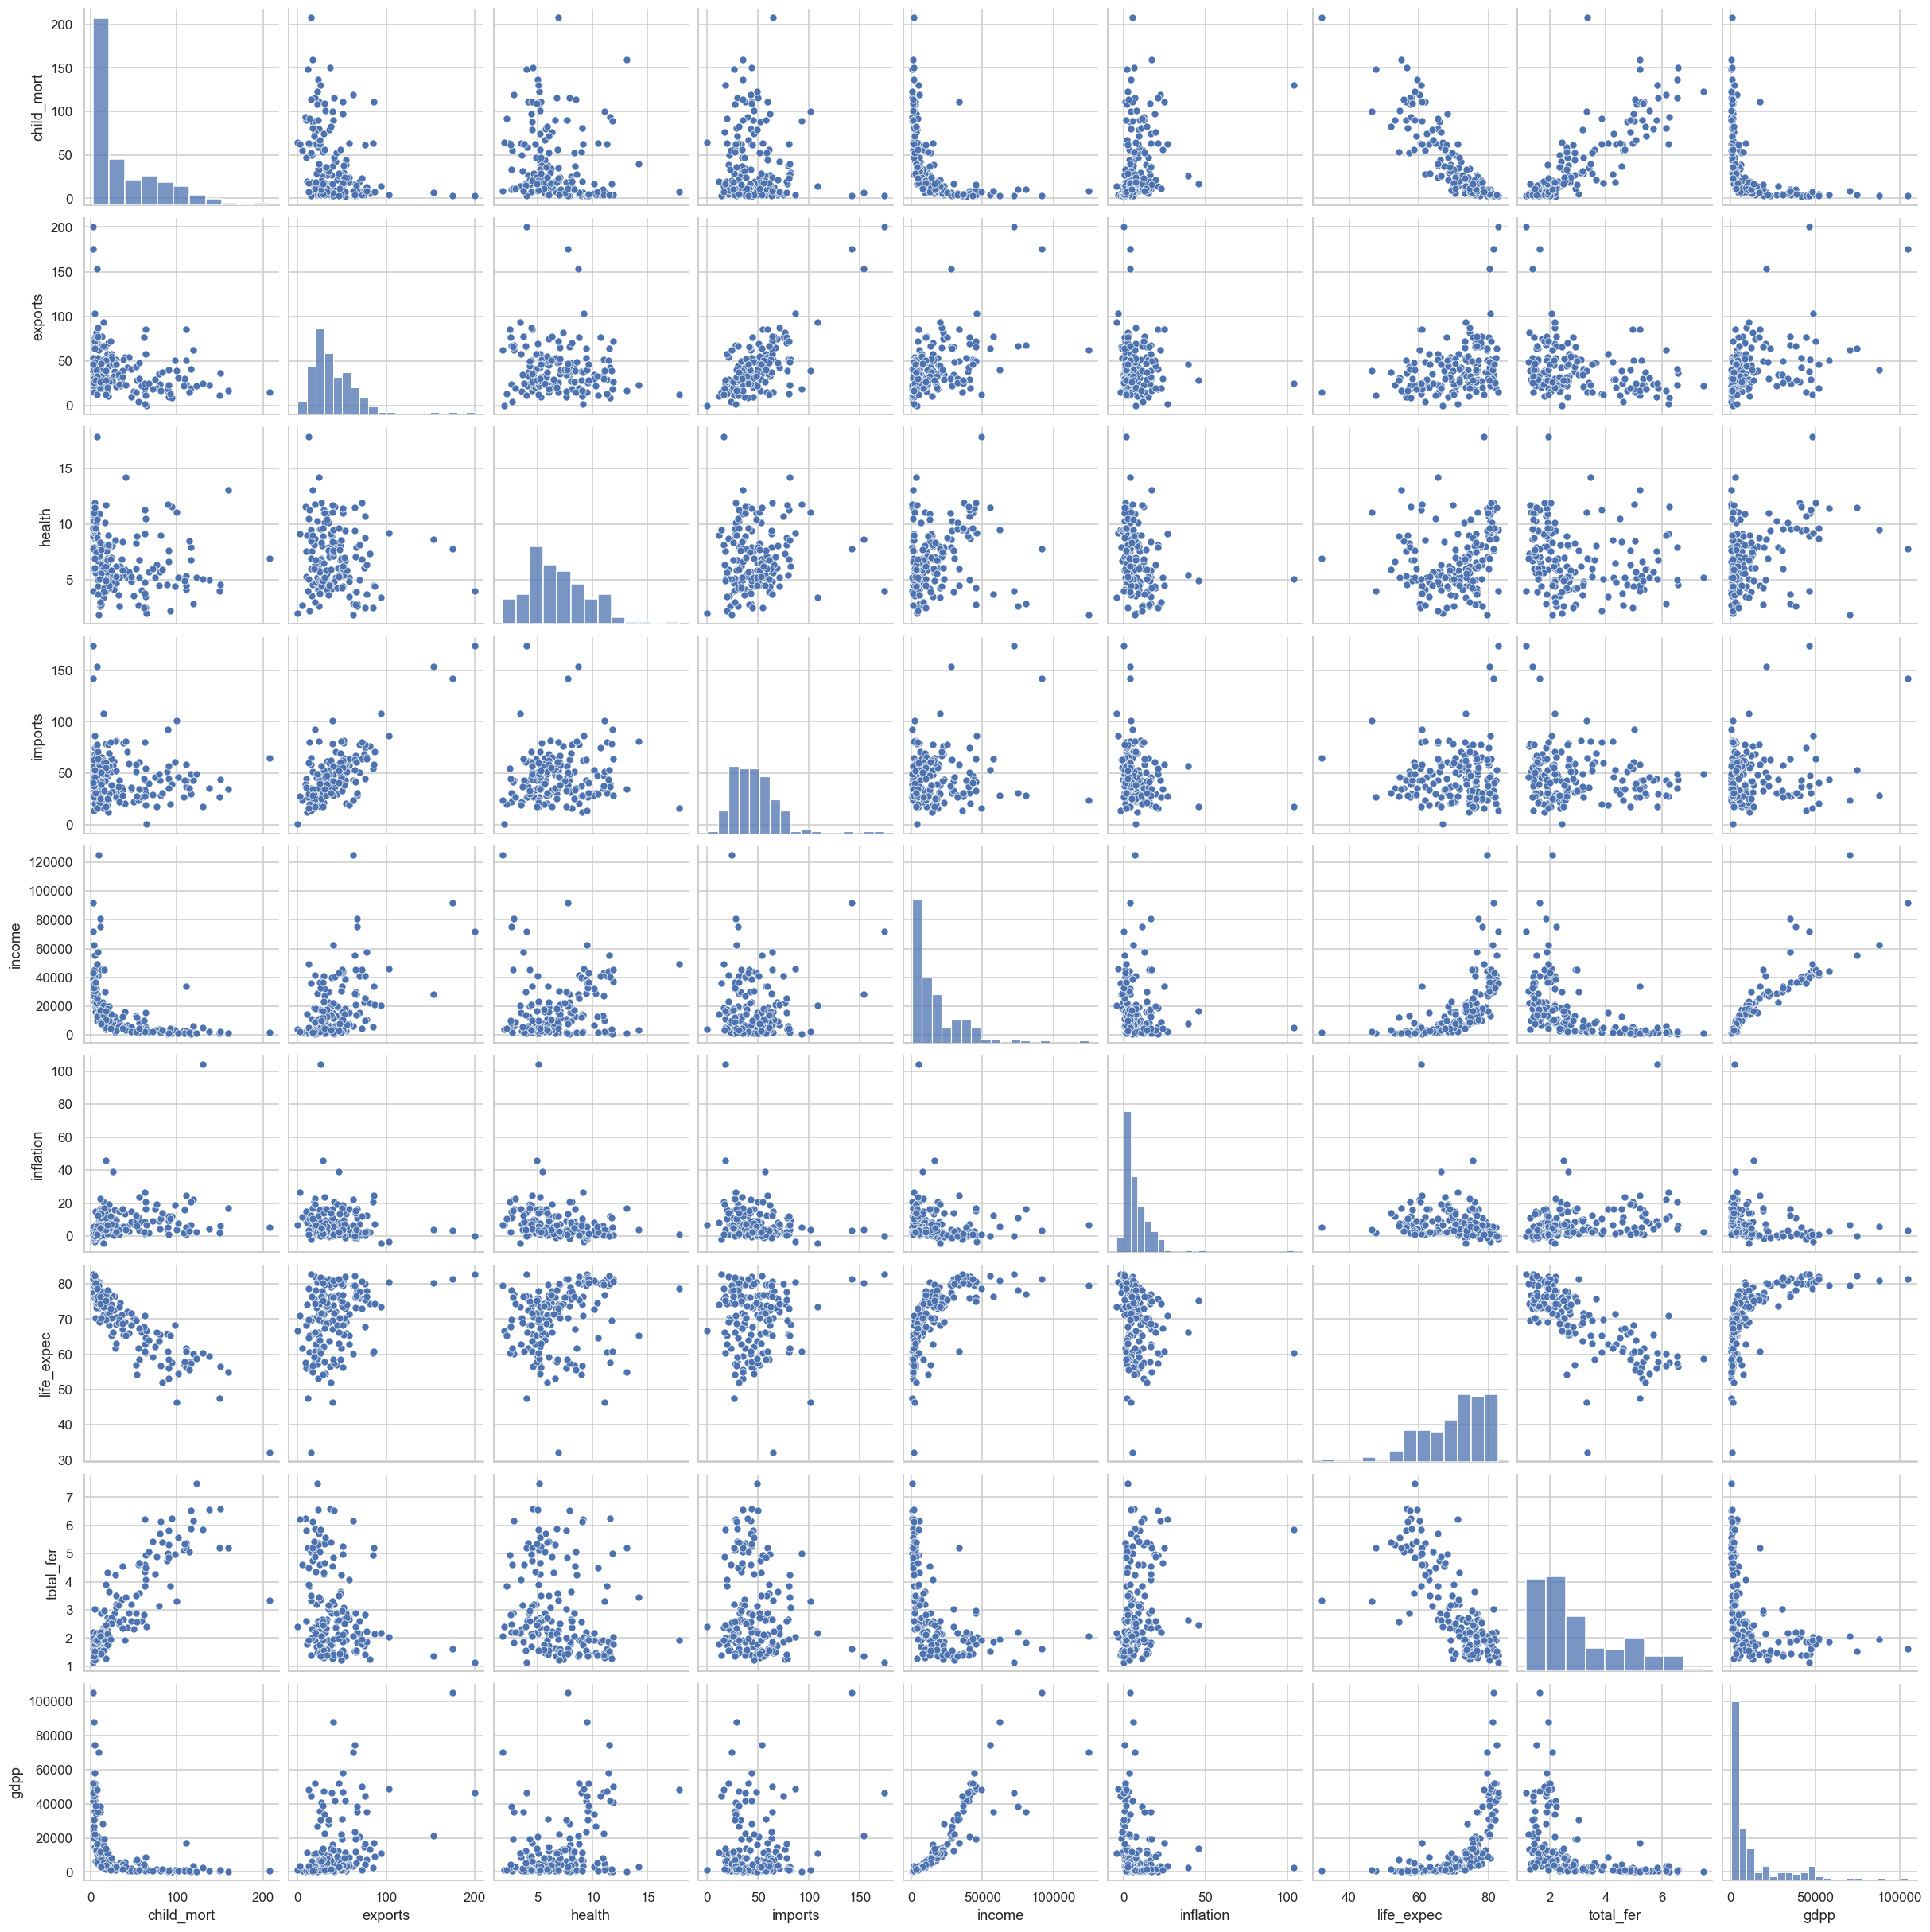

In [4]:
sns.pairplot(df)

### 1.2 Сколько объектов и признаков, какие типы

`country` — текстовый идентификатор (не признак для модели).
Остальные 9 столбцов — числовые признаки.

In [5]:
print(f"Объектов (строк):   {df.shape[0]}")
print(f"Столбцов всего:     {df.shape[1]}")
print(f"Числовых признаков: {df.shape[1] - 1}  (без 'country')")
print()
df.info()

Объектов (строк):   167
Столбцов всего:     10
Числовых признаков: 9  (без 'country')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
# Матрица признаков для анализа (без идентификатора страны)
features = df.drop(columns=["country"])
feature_names = features.columns.tolist()
feature_names

['child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

### 1.3 Пропуски

In [7]:
missing = df.isna().sum()
print("Пропусков по столбцам:")
print(missing)
print(f"\nВсего пропусков в данных: {int(missing.sum())}")
print("Дубликатов строк:", int(df.duplicated().sum()))

Пропусков по столбцам:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Всего пропусков в данных: 0
Дубликатов строк: 0


**Вывод:** пропусков и дубликатов нет — чистить нечего, можно сразу переходить к масштабам и распределениям.

### 1.4 Масштабы признаков — почему без StandardScaler нельзя

Смотрим на `describe()`. Главное здесь — **разброс масштабов между признаками**.

In [8]:
desc = features.describe().T[["mean", "std", "min", "50%", "max"]]
desc

,mean,std,min,50%,max
child_mort,38.27,40.33,2.60,19.30,208.00
exports,41.11,27.41,0.11,35.00,200.00
health,6.82,2.75,1.81,6.32,17.90
imports,46.89,24.21,0.07,43.30,174.00
income,"17,144.69","19,278.07",609.00,"9,960.00","125,000.00"
inflation,7.78,10.57,-4.21,5.39,104.00
life_expec,70.56,8.89,32.10,73.10,82.80
total_fer,2.95,1.51,1.15,2.41,7.49
gdpp,"12,964.16","18,328.70",231.00,"4,660.00","105,000.00"


In [9]:
# Насколько отличаются масштабы признаков (по средним значениям)
means = features.mean()
ratio = means.max() / means.min()
print(f"Самый «крупный» признак по среднему:  {means.idxmax():12s} = {means.max():,.1f}")
print(f"Самый «мелкий»  признак по среднему:  {means.idxmin():12s} = {means.min():,.2f}")
print(f"\nОтношение масштабов:  ~{ratio:,.0f}x")
print("\n=> income и gdpp измеряются в десятках тысяч, а health/total_fer — в единицах.")
print("   Без приведения к одному масштабу евклидово расстояние и дисперсия (для PCA)")
print("   будут определяться почти целиком признаком income/gdpp. Масштабирование обязательно.")

Самый «крупный» признак по среднему:  income       = 17,144.7
Самый «мелкий»  признак по среднему:  total_fer    = 2.95

Отношение масштабов:  ~5,816x

=> income и gdpp измеряются в десятках тысяч, а health/total_fer — в единицах.
   Без приведения к одному масштабу евклидово расстояние и дисперсия (для PCA)
   будут определяться почти целиком признаком income/gdpp. Масштабирование обязательно.


Те же масштабы — наглядно. Ось Y логарифмическая: видно, что `income` и `gdpp`
на **порядки** больше остальных признаков, поэтому без StandardScaler они доминировали бы
и в расстояниях (KMeans), и в дисперсии (PCA).

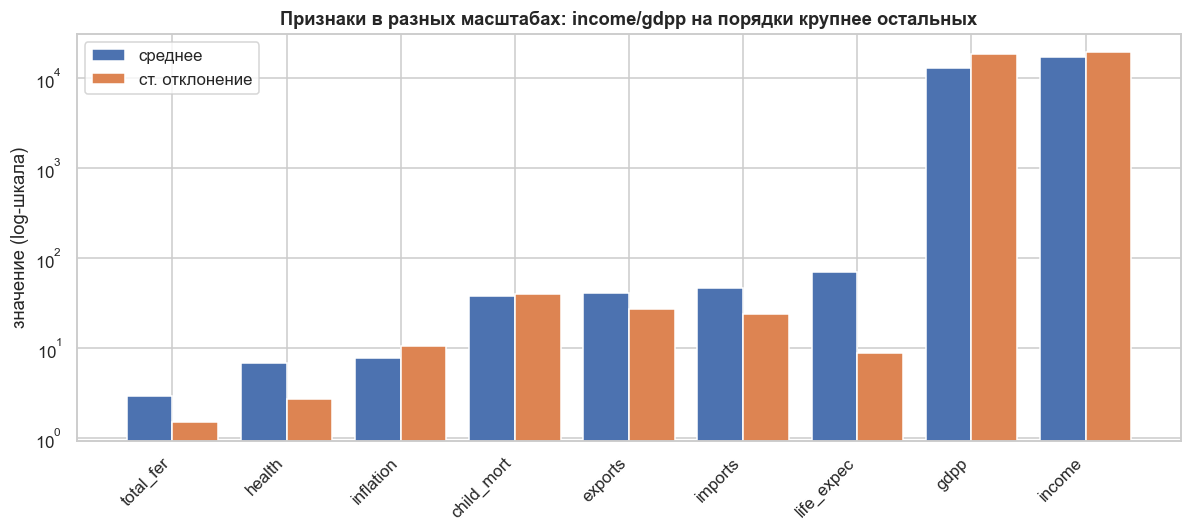

In [10]:
stats = features.agg(["mean", "std"]).T.sort_values("mean")
xpos = np.arange(len(stats))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(xpos - 0.2, stats["mean"], width=0.4, label="среднее", color="#4C72B0")
ax.bar(xpos + 0.2, stats["std"],  width=0.4, label="ст. отклонение", color="#DD8452")
ax.set_yscale("log")
ax.set_xticks(xpos); ax.set_xticklabels(stats.index, rotation=45, ha="right")
ax.set_ylabel("значение (log-шкала)")
ax.set_title("Признаки в разных масштабах: income/gdpp на порядки крупнее остальных",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 1.5 Распределения признаков

Гистограммы показывают форму распределения и сильную правостороннюю скошенность
у «денежных» признаков (`income`, `gdpp`) и у `child_mort` / `inflation`.

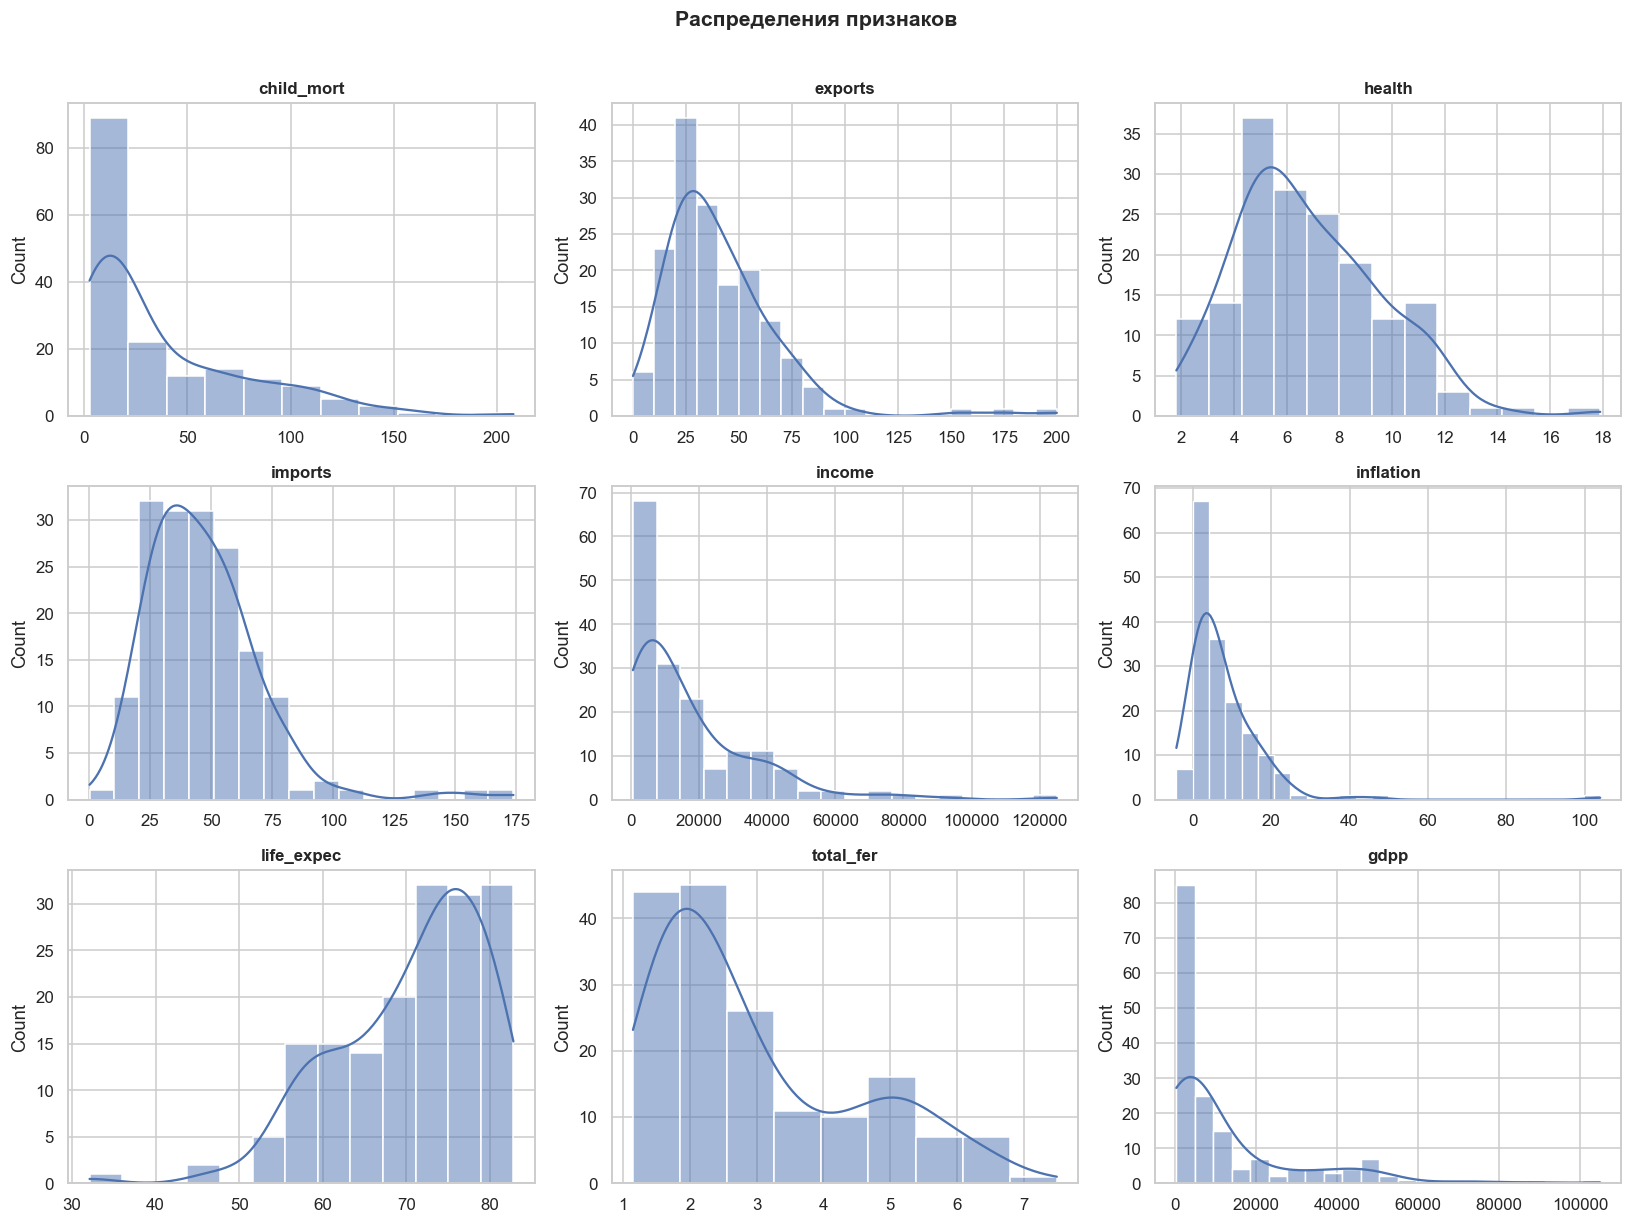

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), feature_names):
    sns.histplot(features[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
fig.suptitle("Распределения признаков", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1.6 Выбросы

Боксплоты на **исходных** данных нечитаемы (разные масштабы), поэтому смотрим
выбросы двумя способами:
1. боксплоты на стандартизованных данных — видно форму и хвосты;
2. подсчёт выбросов по правилу межквартильного размаха (IQR).

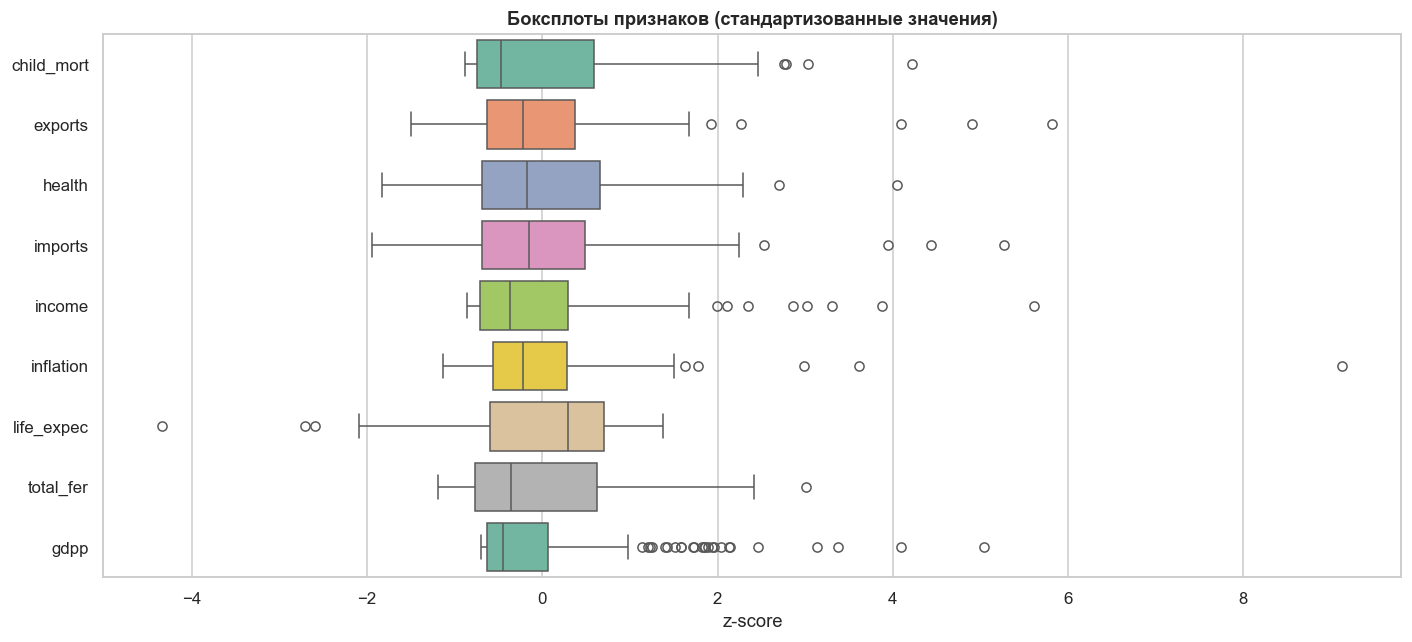

In [12]:
# Боксплоты на стандартизованных значениях (чтобы все признаки были сравнимы)
scaled_preview = pd.DataFrame(
    StandardScaler().fit_transform(features), columns=feature_names
)
plt.figure(figsize=(13, 6))
sns.boxplot(data=scaled_preview, orient="h", palette="Set2")
plt.title("Боксплоты признаков (стандартизованные значения)", fontweight="bold")
plt.xlabel("z-score")
plt.tight_layout()
plt.show()

In [13]:
# Подсчёт выбросов по правилу IQR (1.5 * IQR)
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum()

outl = features.apply(iqr_outliers).sort_values(ascending=False)
outl.name = "n_outliers"
print("Число выбросов по правилу IQR:")
print(outl)
print(f"\nБольше всего выбросов у '{outl.idxmax()}' — это богатые страны "
      f"с очень высоким {outl.idxmax()}.")

Число выбросов по правилу IQR:
gdpp          25
income         8
exports        5
inflation      5
child_mort     4
imports        4
life_expec     3
health         2
total_fer      1
Name: n_outliers, dtype: int64

Больше всего выбросов у 'gdpp' — это богатые страны с очень высоким gdpp.


In [14]:
# Кто эти выбросы у gdpp (богатые страны) и у inflation
print("Топ-5 по gdpp:")
print(df.nlargest(5, "gdpp")[["country", "gdpp", "income", "child_mort"]].to_string(index=False))
print("\nЭкстремальная инфляция:")
print(df.nlargest(3, "inflation")[["country", "inflation"]].to_string(index=False))

Топ-5 по gdpp:
    country   gdpp  income  child_mort
 Luxembourg 105000   91700        2.80
     Norway  87800   62300        3.20
Switzerland  74600   55500        4.50
      Qatar  70300  125000        9.00
    Denmark  58000   44000        4.10

Экстремальная инфляция:
  country  inflation
  Nigeria     104.00
Venezuela      45.90
 Mongolia      39.20


**Вывод по выбросам:** выбросы — это реальные страны (богатые государства по `gdpp`/`income`,
гиперинфляция в Нигерии). Это содержательные крайние случаи, а не ошибки ввода,
поэтому строки **не удаляем**. Но из-за длинных хвостов масштабирование тем более необходимо.

### 1.7 Матрица корреляций

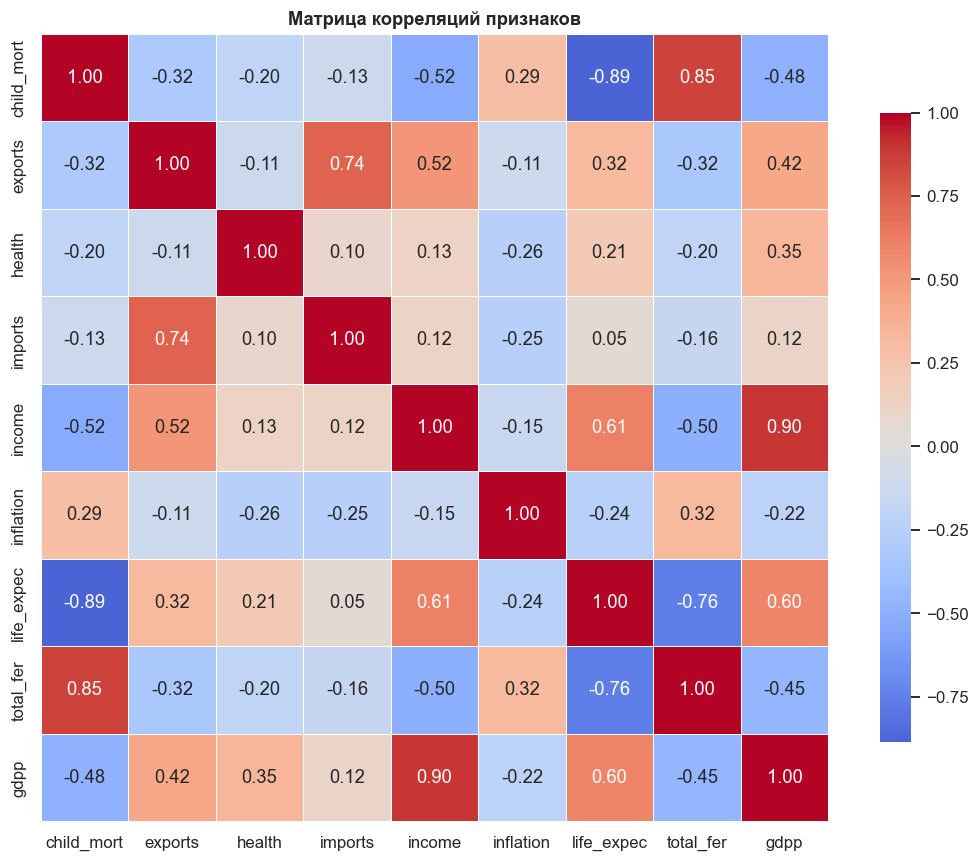

In [15]:
corr = features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Матрица корреляций признаков", fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# Самые сильные связи (по модулю), без диагонали
pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feat_1", "level_1": "feat_2", 0: "corr"})
)
pairs["abs"] = pairs["corr"].abs()
pairs = pairs[pairs["feat_1"] < pairs["feat_2"]].sort_values("abs", ascending=False)
print("Топ-8 самых сильных связей:")
print(pairs.head(8)[["feat_1", "feat_2", "corr"]].to_string(index=False))

Топ-8 самых сильных связей:
    feat_1     feat_2  corr
      gdpp     income  0.90
child_mort life_expec -0.89
child_mort  total_fer  0.85
life_expec  total_fer -0.76
   exports    imports  0.74
    income life_expec  0.61
      gdpp life_expec  0.60
child_mort     income -0.52


**Чего и ожидали:** `child_mort` сильно растёт вместе с `total_fer` (≈ 0.85) и падает
с ростом `life_expec` (≈ −0.89); `income` и `gdpp` почти дублируют друг друга (≈ 0.90).

### 1.8 Находка, которая удивила (для выступления)

> **Доля ВВП, которую страна тратит на здравоохранение (`health`), почти НЕ связана
> с детской смертностью и продолжительностью жизни.**

Интуитивно ждёшь: больше тратят на медицину (в % от ВВП) → меньше детей умирает.
Но корреляция `health` ↔ `child_mort` всего **−0.20**, а `health` ↔ `life_expec` всего **+0.21**.

In [17]:
print("Корреляции health со всеми признаками:")
print(corr["health"].sort_values().round(2))

print("\nПримеры, ломающие интуицию (доля ВВП на медицину высокая, а смертность разная):")
cols = ["country", "health", "child_mort", "income", "gdpp"]
ex = df[df["country"].isin(
    ["United States", "Sierra Leone", "France", "Afghanistan", "Singapore"]
)][cols].sort_values("health", ascending=False)
print(ex.to_string(index=False))

Корреляции health со всеми признаками:
inflation    -0.26
child_mort   -0.20
total_fer    -0.20
exports      -0.11
imports       0.10
income        0.13
life_expec    0.21
gdpp          0.35
health        1.00
Name: health, dtype: float64

Примеры, ломающие интуицию (доля ВВП на медицину высокая, а смертность разная):
      country  health  child_mort  income  gdpp
United States   17.90        7.30   49400 48400
 Sierra Leone   13.10      160.00    1220   399
       France   11.90        4.20   36900 40600
  Afghanistan    7.58       90.20    1610   553
    Singapore    3.96        2.80   72100 46600


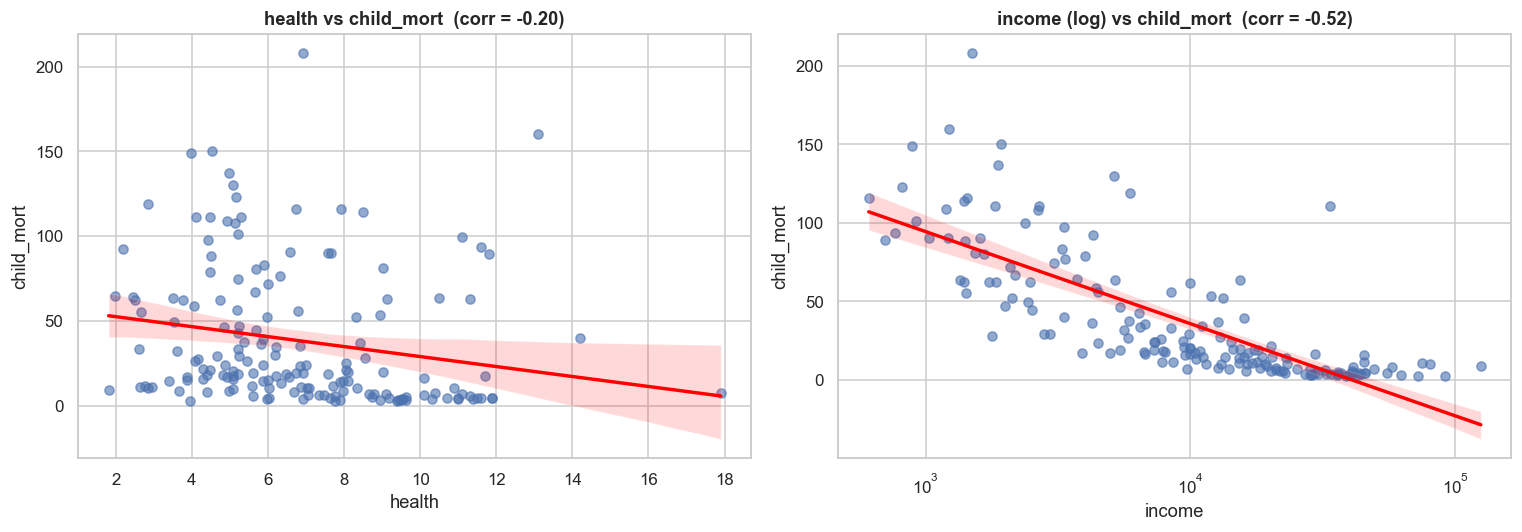

In [18]:
# Наглядно: health почти не объясняет child_mort, а income (в log) — объясняет
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x="health", y="child_mort", ax=ax[0],
            scatter_kws={"alpha": .6}, line_kws={"color": "red"})
ax[0].set_title(f"health vs child_mort  (corr = {corr.loc['health','child_mort']:.2f})",
                fontweight="bold")

sns.regplot(data=df, x="income", y="child_mort", ax=ax[1], logx=True,
            scatter_kws={"alpha": .6}, line_kws={"color": "red"})
ax[1].set_xscale("log")
ax[1].set_title(f"income (log) vs child_mort  (corr = {corr.loc['income','child_mort']:.2f})",
                fontweight="bold")

plt.tight_layout()
plt.show()

**Что это значит:** на детскую смертность влияет не *доля* ВВП на здравоохранение,
а **абсолютный уровень дохода/богатства страны** (`income`, `gdpp`).
Бедная страна может тратить на медицину большой % ВВП, но в абсолютных деньгах — копейки.
Это важно учитывать при интерпретации кластеров: «развитость» страны определяют
деньги и демография, а не доля расходов на медицину.

### 1.9 Приведение к одному масштабу — StandardScaler

Стандартизуем все числовые признаки: у каждого станет среднее ≈ 0 и стандартное
отклонение = 1. Это нужно и для кластеризации (евклидово расстояние), и для PCA
(дисперсия). `country` сохраняем отдельно как индекс.

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

df_scaled = pd.DataFrame(X_scaled, columns=feature_names, index=df["country"])
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
Albania,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
Algeria,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
Angola,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
Antigua and Barbuda,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04


In [20]:
# Проверка: после StandardScaler mean ≈ 0, std = 1 у всех признаков
check = pd.DataFrame({
    "mean_after": df_scaled.mean().round(3),
    "std_after":  df_scaled.std(ddof=0).round(3),
})
print(check)
print("\nВсе средние ≈ 0, все стандартные отклонения = 1 — масштабы выровнены.")

            mean_after  std_after
child_mort       -0.00       1.00
exports           0.00       1.00
health            0.00       1.00
imports           0.00       1.00
income           -0.00       1.00
inflation        -0.00       1.00
life_expec        0.00       1.00
total_fer         0.00       1.00
gdpp              0.00       1.00

Все средние ≈ 0, все стандартные отклонения = 1 — масштабы выровнены.


### Итоги Шага 1

- **167 объектов (стран)** и **9 числовых признаков** (+ `country` как идентификатор).
- **Пропусков и дубликатов нет.**
- Масштабы признаков отличаются в **тысячи раз** (`income`/`gdpp` против `health`/`total_fer`)
  → масштабирование обязательно.
- Распределения «денежных» признаков и `child_mort`/`inflation` сильно скошены вправо;
  **выбросы — реальные страны**, не ошибки, поэтому их не удаляем.
- Сильнейшие связи: `life_expec`↔`child_mort` (−0.89), `total_fer`↔`child_mort` (0.85),
  `income`↔`gdpp` (0.90).
- **Удивившая находка:** доля ВВП на здравоохранение почти не связана с детской
  смертностью — решают абсолютный доход и богатство страны.
- Данные стандартизованы (`df_scaled`) и готовы к кластеризации и PCA на следующих шагах.

---
# Шаг 2. Кластеризация (KMeans)

Меток у нас нет — это **обучение без учителя**, поэтому структуру в данных ищем сами.
Запускаем KMeans на **масштабированных** данных (`df_scaled` из Шага 1).

**Главный вопрос — сколько кластеров `k`.** Его нельзя угадывать. Мы определим `k`
двумя независимыми способами и сопоставим их:

1. **Метод локтя (elbow).** Смотрим `inertia` — сумму квадратов расстояний от точек
   до центра своего кластера. С ростом `k` inertia всегда падает (при `k = n` она = 0).
   Нам нужен «локоть» — `k`, после которого добавление новых кластеров почти не
   уменьшает inertia (резкое падение сменяется пологим).

2. **Коэффициент силуэта (silhouette).** Для каждой точки сравнивает, насколько она
   близка к своему кластеру против ближайшего соседнего. Диапазон от −1 до +1, чем
   **больше — тем лучше** разделение. В отличие от inertia, силуэт можно сравнивать
   между разными `k` напрямую.

И, как требует задание, **не верим первому `k` на слово** — проверим соседние значения
(размеры и состав кластеров), чтобы убедиться, что выбранное `k` даёт осмысленную,
а не вырожденную структуру.

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)

# Работаем на стандартизованной матрице из Шага 1
X = X_scaled  # shape: (167, 9), mean=0 / std=1 по каждому признаку
RANDOM_STATE = 42
print("Матрица для кластеризации:", X.shape)

Матрица для кластеризации: (167, 9)


### 2.1 Считаем метрики для диапазона k

Прогоняем KMeans для `k` от 2 до 10 и собираем сразу четыре метрики, чтобы решение
не опиралось на один-единственный критерий:

- **inertia** — для метода локтя (меньше = плотнее кластеры, но всегда падает с ростом k);
- **silhouette** — главный критерий качества разделения (больше = лучше);
- **Calinski–Harabasz** — отношение межкластерного разброса к внутрикластерному (больше = лучше);
- **Davies–Bouldin** — среднее «сходство» кластера с самым похожим соседом (меньше = лучше).

`n_init=10` — KMeans 10 раз стартует из разных случайных центров и берёт лучший
результат (KMeans чувствителен к инициализации); `random_state=42` — для
воспроизводимости.

In [22]:
K_RANGE = range(2, 11)
rows = []

# inertia для k=1 нужна отдельно — силуэт для одного кластера не определён
inertia_k1 = KMeans(n_clusters=1, random_state=RANDOM_STATE, n_init=10).fit(X).inertia_

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
    })

metrics = pd.DataFrame(rows).set_index("k")
# на сколько % падает inertia при переходе к следующему k
inertia_full = pd.concat([pd.Series({1: inertia_k1}), metrics["inertia"]])
metrics["inertia_drop_%"] = (-inertia_full.pct_change() * 100).reindex(metrics.index).round(1)
metrics.round(3)

,inertia,silhouette,calinski_harabasz,davies_bouldin,inertia_drop_%
k,,,,,
2,"1,050.21",0.29,71.14,1.30,30.10
3,831.42,0.28,66.23,1.28,20.80
4,700.52,0.30,62.24,1.05,15.70
5,620.16,0.30,57.65,0.87,11.50
6,558.47,0.23,54.46,1.08,9.90
7,495.81,0.25,54.17,0.99,11.20
8,457.59,0.24,51.89,1.13,7.70
9,427.80,0.21,49.64,1.15,6.50
10,403.23,0.20,47.58,1.18,5.70


### 2.2 Графики: локоть и силуэт

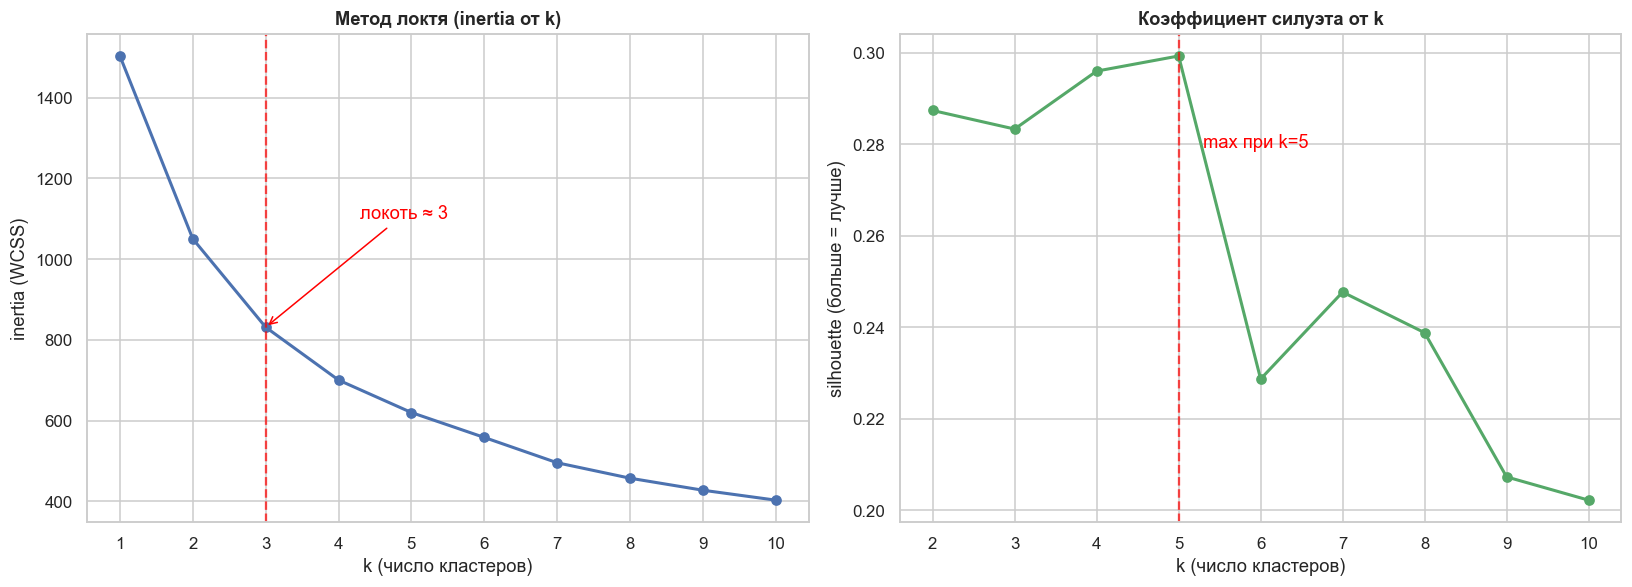

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Метод локтя ---
ks_full = [1] + list(K_RANGE)
ax[0].plot(ks_full, inertia_full.values, "o-", color="#4C72B0", lw=2)
ax[0].set_title("Метод локтя (inertia от k)", fontweight="bold")
ax[0].set_xlabel("k (число кластеров)"); ax[0].set_ylabel("inertia (WCSS)")
ax[0].set_xticks(ks_full)
ax[0].axvline(3, color="red", ls="--", alpha=.7)
ax[0].annotate("локоть ≈ 3", xy=(3, metrics.loc[3, "inertia"]),
               xytext=(4.3, 1100), color="red",
               arrowprops=dict(arrowstyle="->", color="red"))

# --- Силуэт ---
ax[1].plot(metrics.index, metrics["silhouette"], "o-", color="#55A868", lw=2)
ax[1].set_title("Коэффициент силуэта от k", fontweight="bold")
ax[1].set_xlabel("k (число кластеров)"); ax[1].set_ylabel("silhouette (больше = лучше)")
ax[1].set_xticks(list(K_RANGE))
best_sil = metrics["silhouette"].idxmax()
ax[1].axvline(best_sil, color="red", ls="--", alpha=.7)
ax[1].annotate(f"max при k={best_sil}", xy=(best_sil, metrics["silhouette"].max()),
               xytext=(best_sil + .3, metrics["silhouette"].max() - .02), color="red")

plt.tight_layout()
plt.show()

**Как читаем графики:**

- **Локоть.** Самые крупные падения inertia: `k=1→2` и `k=2→3`. После `k=3` кривая
  заметно выполаживается — каждый следующий кластер срезает всё меньше inertia
  (см. столбец `inertia_drop_%`: после тройки прирост качества резко падает).
  Локоть — около **k=3**.

- **Силуэт.** Кривая почти плоская в диапазоне `k=2…5` (значения ~0.28–0.30) с очень
  небольшим формальным максимумом справа. То есть силуэт **не указывает уверенно** на
  одно конкретное `k` и точно не противоречит тройке.

Метрики не совпадают идеально (это норма!): локоть тянет к 3, силуэт почти не
различает 2–5. Поэтому делаем то, что требует задание — **проверяем соседние k**.

### 2.3 Не верим первому k — проверяем соседние значения

Чтобы понять, что стоит за «плоским» силуэтом, посмотрим на **размеры и смысл**
кластеров для `k = 2, 3, 4, 5`. Хорошее `k` должно давать кластеры разумного
размера и содержательную интерпретацию, а не отрезать по одной стране-выбросу.

In [24]:
def cluster_summary(k):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    tmp = df.copy()
    tmp["cluster"] = labels
    prof = (tmp.groupby("cluster")
              .agg(n=("country", "size"),
                   child_mort=("child_mort", "mean"),
                   income=("income", "mean"),
                   gdpp=("gdpp", "mean"))
              .round(0))
    # сортируем кластеры по богатству для читаемости
    prof = prof.sort_values("gdpp")
    return labels, prof

for k in [2, 3, 4, 5]:
    labels, prof = cluster_summary(k)
    print(f"===== k = {k}  |  silhouette = {silhouette_score(X, labels):.3f} "
          f"|  размеры кластеров = {sorted(prof['n'].astype(int).tolist())}")
    print(prof.to_string())
    print()

===== k = 2  |  silhouette = 0.287 |  размеры кластеров = [68, 99]
          n  child_mort    income      gdpp
cluster                                    
1        68       76.00  4,227.00  1,981.00
0        99       12.00 26,017.00 20,508.00

===== k = 3  |  silhouette = 0.283 |  размеры кластеров = [36, 47, 84]
          n  child_mort    income      gdpp
cluster                                    
1        47       93.00  3,942.00  1,922.00
2        84       22.00 12,306.00  6,486.00
0        36        5.00 45,672.00 42,494.00

===== k = 4  |  silhouette = 0.296 |  размеры кластеров = [3, 32, 47, 85]
          n  child_mort    income      gdpp
cluster                                    
1        47       93.00  3,942.00  1,922.00
2        85       22.00 12,671.00  6,520.00
0        32        5.00 44,022.00 42,119.00
3         3        4.00 64,033.00 57,567.00

===== k = 5  |  silhouette = 0.299 |  размеры кластеров = [1, 3, 32, 47, 84]
          n  child_mort    income      gdpp
clus

**Что видно из проверки соседей:**

| k | Что получается | Вывод |
|---|---|---|
| **2** | только «бедные ↔ богатые». Теряется средняя группа развивающихся стран | слишком грубо |
| **3** | бедные / развивающиеся / развитые — сбалансированные размеры (≈ 36 / 47 / 84) | **осмысленно** |
| **4** | от богатых отделяется крошечный кластер из ~3 стран (Люксембург, Катар…) | нишевый сплит |
| **5** | появляется кластер из **одной** страны-выброса (гипер-смертность) | вырождение |

Вот и разгадка «плоского» силуэта: формальный максимум при больших `k` достигается
не за счёт новой структуры, а за счёт **отрезания крошечных кластеров-выбросов**
(3 страны, затем 1 страна). Такие сплиты слегка приподнимают силуэт, но не несут
полезного смысла для задачи (группировка стран по уровню развития).

**Вывод:** `k=4` и `k=5` не дают новой осмысленной структуры — только дробят хвосты.

### 2.4 Выбор k и обоснование

**Берём `k = 3`.** Обоснование (по совокупности критериев, а не по одному):

1. **Локоть** даёт самый чёткий сигнал именно на `k=3` — дальше inertia падает уже полого.
2. **Силуэт** в районе `k=3` практически не отличается от соседних 2 / 4 / 5
   (разница в пределах шума), то есть тройку он **не отвергает**.
3. **Проверка соседей** показала: `k=2` слишком груб, а `k=4–5` лишь отрезают
   кластеры из 1–3 стран-выбросов — это не новая структура.
4. **Интерпретируемость**: три кластера чисто ложатся на «бедные / развивающиеся /
   развитые» — ровно то деление, ради которого этот датасет и существует.

То есть `k=3` — это пересечение «локтя», «силуэта, который не против» и
«осмысленной интерпретации». Закрепляем финальную модель.

In [25]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X)

df["cluster"] = cluster_labels
df_scaled["cluster"] = cluster_labels

print(f"Финальная модель: KMeans(k={K_FINAL})")
print(f"Силуэт: {silhouette_score(X, cluster_labels):.3f}")
print(f"Inertia: {kmeans.inertia_:.1f}")
print("\nРазмеры кластеров:")
print(df['cluster'].value_counts().sort_index().to_string())

Финальная модель: KMeans(k=3)
Силуэт: 0.283
Inertia: 831.4

Размеры кластеров:
cluster
0    36
1    47
2    84


### 2.5 Профиль и интерпретация кластеров

Смотрим средние значения признаков по кластерам в **исходных** единицах (так понятнее,
чем в z-оценках) и присваиваем кластерам человекочитаемые названия по уровню развития.

In [26]:
profile = df.groupby("cluster")[feature_names].mean().round(1)
profile.insert(0, "n_countries", df["cluster"].value_counts().sort_index())
profile

,n_countries,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,,
0,36,5.00,58.70,8.80,51.50,"45,672.20",2.70,80.10,1.80,"42,494.40"
1,47,93.00,29.20,6.40,42.30,"3,942.40",12.00,59.20,5.00,"1,922.40"
2,84,21.90,40.20,6.20,47.50,"12,305.60",7.60,72.80,2.30,"6,486.50"


In [27]:
# Назовём кластеры по уровню развития (упорядочив по gdpp), устойчиво к нумерации
order = df.groupby("cluster")["gdpp"].mean().sort_values().index.tolist()
names = {order[0]: "Бедные / нуждающиеся",
         order[1]: "Развивающиеся",
         order[2]: "Развитые"}
df["cluster_name"] = df["cluster"].map(names)

print("Соответствие номеров и названий кластеров:")
for c in sorted(names): print(f"  cluster {c}  ->  {names[c]}")

print("\nПримеры стран в каждом кластере:")
for c in order:
    sample = df.loc[df["cluster"] == c, "country"].head(6).tolist()
    print(f"\n[{names[c]}]  (n={int((df['cluster']==c).sum())})")
    print("   ", ", ".join(sample), "...")

Соответствие номеров и названий кластеров:
  cluster 0  ->  Развитые
  cluster 1  ->  Бедные / нуждающиеся
  cluster 2  ->  Развивающиеся

Примеры стран в каждом кластере:

[Бедные / нуждающиеся]  (n=47)
    Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi ...

[Развивающиеся]  (n=84)
    Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan ...

[Развитые]  (n=36)
    Australia, Austria, Bahrain, Belgium, Brunei, Canada ...


### 2.6 Силуэт-диаграмма для выбранного k=3

Финальная проверка качества: на диаграмме видно силуэт каждой страны внутри своего
кластера. Почти все значения положительные (точки «на своём месте»); красная линия —
средний силуэт. Отрицательные «хвосты» — пограничные страны между группами, их немного.

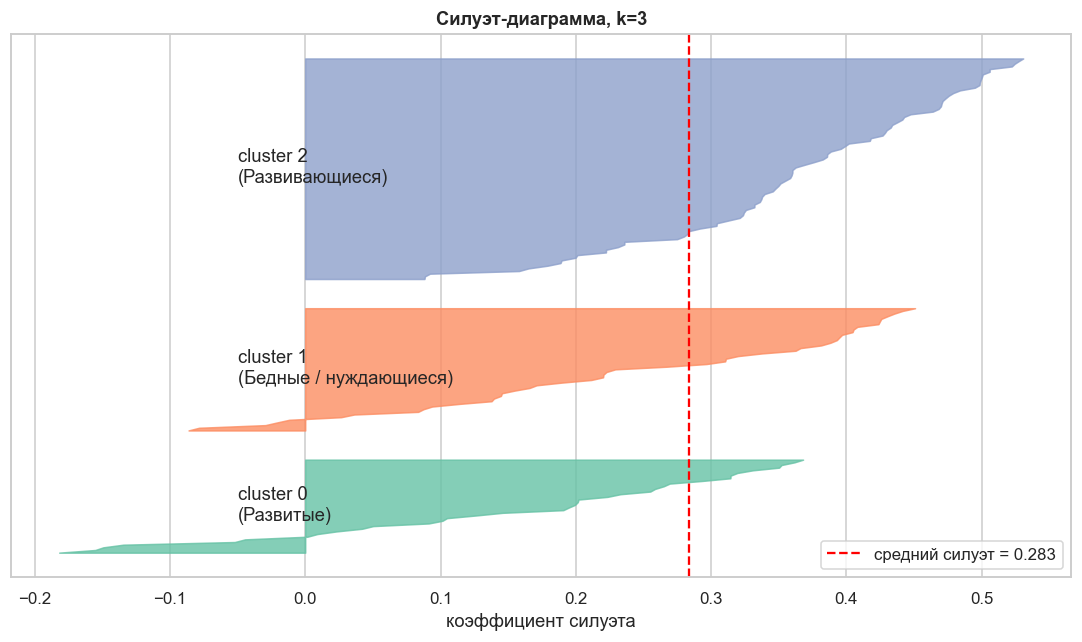

In [28]:
sample_sil = silhouette_samples(X, cluster_labels)
avg_sil = silhouette_score(X, cluster_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
palette = sns.color_palette("Set2", K_FINAL)
for i in range(K_FINAL):
    vals = np.sort(sample_sil[cluster_labels == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=palette[i], edgecolor=palette[i], alpha=.8)
    ax.text(-0.05, y_lower + 0.5 * len(vals), f"cluster {i}\n({names[i]})", va="center")
    y_lower = y_upper + 10

ax.axvline(avg_sil, color="red", ls="--", label=f"средний силуэт = {avg_sil:.3f}")
ax.set_title(f"Силуэт-диаграмма, k={K_FINAL}", fontweight="bold")
ax.set_xlabel("коэффициент силуэта"); ax.set_yticks([])
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Итоги Шага 2

- Кластеризацию делали на **масштабированных** данных — иначе `income`/`gdpp` исказили бы расстояния.
- **k не угадывали**: построили метод локтя (`inertia` от `k`) и коэффициент силуэта.
  Локоть указал на **k=3**, силуэт в диапазоне 2–5 почти не различает варианты.
- **Проверили соседние k (2, 3, 4, 5)**: `k=2` слишком груб; `k=4–5` лишь отрезают
  кластеры из 1–3 стран-выбросов и не дают новой осмысленной структуры — поэтому
  формальный «пик» силуэта справа обманчив.
- **Выбрали k=3** как пересечение локтя, не возражающего силуэта и интерпретируемости.
- Получили три осмысленные группы стран: **бедные / развивающиеся / развитые** —
  они различаются прежде всего детской смертностью, доходом и ВВП на душу населения.
- Метки кластеров сохранены в `df["cluster"]` / `df["cluster_name"]` для следующих шагов (PCA и визуализация).

---
# Шаг 3. Создание прогнозного столбца

Номера кластеров, которые выдал KMeans на Шаге 2, — **это и есть наша новая метка**.
В исходных данных целевого столбца не было; мы его **сконструировали сами** из структуры
данных. С этого момента у задачи появилась цель (target), которой раньше не существовало.

Что делаем на этом шаге:

1. Закрепляем номер кластера как отдельный столбец-метку `target` в таблице.
2. Даём кластерам **человеческие имена по их средним признакам**
   (а не «кластер 0 / 1 / 2»). Имя должно объяснять, **чем группа отличается** от других —
   например, «высокий доход, низкая детская смертность».

Чтобы имена были не «на глаз», а обоснованы данными, мы сначала посчитаем **средний
z-профиль** каждого кластера (на сколько стандартных отклонений признаки группы выше
или ниже среднего по миру), а уже из него выведем названия.

### 3.1 Закрепляем метку как прогнозный столбец `target`

`target` — это и есть наша сконструированная цель (номер кластера). Дублируем её явно,
чтобы подчеркнуть смену роли: теперь это не вспомогательная разметка, а **целевая переменная**.

In [29]:
# Номер кластера из KMeans -> наша новая целевая метка
df["target"] = df["cluster"]

print("Появился прогнозный столбец 'target'. Распределение объектов по классам:")
print(df["target"].value_counts().sort_index().to_string())
print(f"\nВсего классов (целевых): {df['target'].nunique()}")
df[["country", "child_mort", "income", "gdpp", "target"]].head()

Появился прогнозный столбец 'target'. Распределение объектов по классам:
target
0    36
1    47
2    84

Всего классов (целевых): 3


,country,child_mort,income,gdpp,target
0,Afghanistan,90.20,1610,553,1
1,Albania,16.60,9930,4090,2
2,Algeria,27.30,12900,4460,2
3,Angola,119.00,5900,3530,1
4,Antigua and Barbuda,10.30,19100,12200,2


### 3.2 На чём основываем имена — средний z-профиль кластеров

Для каждого кластера считаем средние **стандартизованных** признаков. Значение около `+1`
означает «в среднем на одно стандартное отклонение выше мира», около `−1` — «ниже».
Так сразу видно, чем каждая группа выделяется.

In [30]:
z_profile = df_scaled.groupby("cluster")[feature_names].mean().round(2)
z_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,-0.83,0.65,0.73,0.19,1.48,-0.48,1.08,-0.79,1.62
1,1.36,-0.44,-0.16,-0.19,-0.69,0.40,-1.28,1.36,-0.60
2,-0.41,-0.03,-0.22,0.02,-0.25,-0.02,0.25,-0.42,-0.35


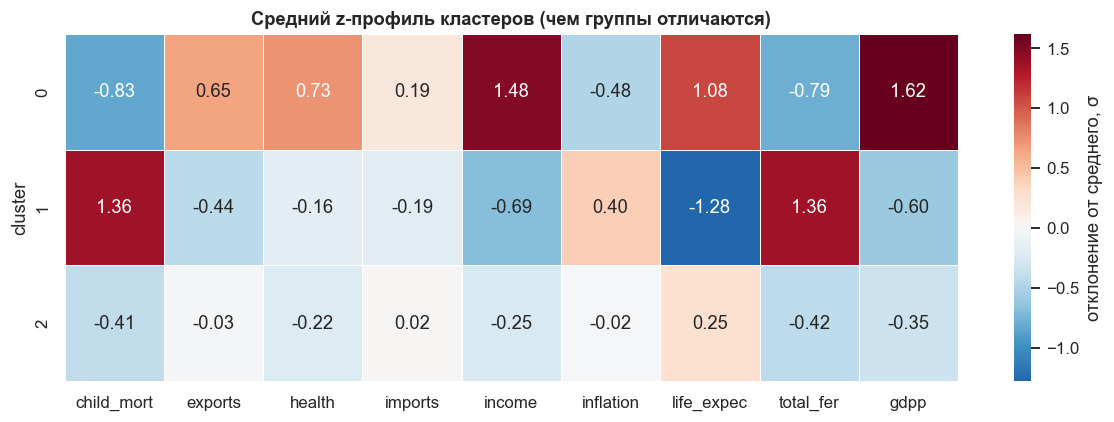

In [31]:
# Тепловая карта z-профиля: красное = выше среднего, синее = ниже среднего
plt.figure(figsize=(11, 4))
sns.heatmap(z_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=.5, cbar_kws={"label": "отклонение от среднего, σ"})
plt.title("Средний z-профиль кластеров (чем группы отличаются)", fontweight="bold")
plt.ylabel("cluster"); plt.xlabel("")
plt.tight_layout()
plt.show()

### 3.3 Автоматическое описание отличий каждой группы

Чтобы имя действительно объясняло отличия, программно выберем для каждого кластера
признаки, которые сильнее всего отклоняются от среднего (|z| ≥ 0.6), и опишем их
направление словами.

In [32]:
# Готовые фразы для каждого признака (высокий / низкий) — грамматически корректные
RU = {                          # feature: (если z>0, если z<0)
    "child_mort": ("высокая детская смертность", "низкая детская смертность"),
    "exports":    ("высокий экспорт",            "низкий экспорт"),
    "health":     ("высокие расходы на медицину", "низкие расходы на медицину"),
    "imports":    ("высокий импорт",             "низкий импорт"),
    "income":     ("высокий доход на человека",  "низкий доход на человека"),
    "inflation":  ("высокая инфляция",           "низкая инфляция"),
    "life_expec": ("высокая продолжительность жизни", "низкая продолжительность жизни"),
    "total_fer":  ("высокая рождаемость",        "низкая рождаемость"),
    "gdpp":       ("высокий ВВП на душу",        "низкий ВВП на душу"),
}

def describe_cluster(z_row, thresh=0.6):
    parts = []
    for feat, z in z_row.sort_values(key=abs, ascending=False).items():
        if abs(z) >= thresh:
            parts.append(RU[feat][0] if z > 0 else RU[feat][1])
    return ", ".join(parts)

print("Чем выделяется каждый кластер (по признакам с |z| ≥ 0.6):\n")
for c in z_profile.index:
    print(f"cluster {c}: {describe_cluster(z_profile.loc[c])}")

Чем выделяется каждый кластер (по признакам с |z| ≥ 0.6):

cluster 0: высокий ВВП на душу, высокий доход на человека, высокая продолжительность жизни, низкая детская смертность, низкая рождаемость, высокие расходы на медицину, высокий экспорт
cluster 1: высокая детская смертность, высокая рождаемость, низкая продолжительность жизни, низкий доход на человека, низкий ВВП на душу
cluster 2: 


### 3.4 Присваиваем человеческие имена

На основе z-профиля видно три отчётливо разных портрета. Даём короткие имена,
каждое из которых называет ключевые отличительные признаки группы:

| Кластер | Портрет по признакам | Человеческое имя |
|---|---|---|
| богатые (income↑, gdpp↑, life_expec↑, child_mort↓) | живут долго, дети почти не умирают, высокий доход | **«Высокий доход, низкая детская смертность»** |
| бедные (child_mort↑, total_fer↑, life_expec↓, income↓) | много рождений и детских смертей, короткая жизнь, мало денег | **«Низкий доход, высокая смертность и рождаемость»** |
| средние (всё около среднего) | промежуточная группа без ярких крайностей | **«Средний доход, показатели около среднего»** |

Имена назначаем устойчиво — по порядку `gdpp`, чтобы они не «поехали» при другой
нумерации кластеров.

In [33]:
# Порядок кластеров по богатству (gdpp) -> устойчивое присвоение имён
order_by_gdpp = df.groupby("target")["gdpp"].mean().sort_values().index.tolist()
poor, mid, rich = order_by_gdpp  # от беднейшего к богатейшему

target_names = {
    poor: "Низкий доход, высокая смертность и рождаемость",
    mid:  "Средний доход, показатели около среднего",
    rich: "Высокий доход, низкая детская смертность",
}

df["target_name"] = df["target"].map(target_names)

print("Соответствие номера кластера и человеческого имени:")
for c in sorted(target_names):
    print(f"  target {c}  ->  «{target_names[c]}»")

Соответствие номера кластера и человеческого имени:
  target 0  ->  «Высокий доход, низкая детская смертность»
  target 1  ->  «Низкий доход, высокая смертность и рождаемость»
  target 2  ->  «Средний доход, показатели около среднего»


### 3.5 Итоговая таблица с прогнозным столбцом

Метка готова в двух видах: числовой `target` (для моделей) и `target_name`
(для людей и для выступления). Проверяем, что имена согласуются со средними признаками.

In [34]:
# Сводка по именованным группам в исходных единицах
named_profile = (df.groupby("target_name")
                   .agg(n_countries=("country", "size"),
                        child_mort=("child_mort", "mean"),
                        income=("income", "mean"),
                        gdpp=("gdpp", "mean"),
                        life_expec=("life_expec", "mean"),
                        total_fer=("total_fer", "mean"))
                   .round(1)
                   .sort_values("gdpp"))
named_profile

,n_countries,child_mort,income,gdpp,life_expec,total_fer
target_name,,,,,,
"Низкий доход, высокая смертность и рождаемость",47,93.00,"3,942.40","1,922.40",59.20,5.00
"Средний доход, показатели около среднего",84,21.90,"12,305.60","6,486.50",72.80,2.30
"Высокий доход, низкая детская смертность",36,5.00,"45,672.20","42,494.40",80.10,1.80


In [35]:
# Примеры стран в каждой именованной группе
for c in order_by_gdpp:
    name = target_names[c]
    sample = df.loc[df["target"] == c, "country"].head(8).tolist()
    print(f"«{name}»  (n = {int((df['target'] == c).sum())})")
    print("   ", ", ".join(sample), "...\n")

«Низкий доход, высокая смертность и рождаемость»  (n = 47)
    Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic ...

«Средний доход, показатели около среднего»  (n = 84)
    Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh ...

«Высокий доход, низкая детская смертность»  (n = 36)
    Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic ...



In [36]:
# Финальный вид таблицы с прогнозным столбцом
df[["country", "child_mort", "income", "gdpp", "life_expec",
    "target", "target_name"]].head(12)

,country,child_mort,income,gdpp,life_expec,target,target_name
0,Afghanistan,90.20,1610,553,56.20,1,"Низкий доход, высокая смертность и рождаемость"
1,Albania,16.60,9930,4090,76.30,2,"Средний доход, показатели около среднего"
2,Algeria,27.30,12900,4460,76.50,2,"Средний доход, показатели около среднего"
3,Angola,119.00,5900,3530,60.10,1,"Низкий доход, высокая смертность и рождаемость"
4,Antigua and Barbuda,10.30,19100,12200,76.80,2,"Средний доход, показатели около среднего"
5,Argentina,14.50,18700,10300,75.80,2,"Средний доход, показатели около среднего"
6,Armenia,18.10,6700,3220,73.30,2,"Средний доход, показатели около среднего"
7,Australia,4.80,41400,51900,82.00,0,"Высокий доход, низкая детская смертность"
8,Austria,4.30,43200,46900,80.50,0,"Высокий доход, низкая детская смертность"
9,Azerbaijan,39.20,16000,5840,69.10,2,"Средний доход, показатели около среднего"


### Итоги Шага 3

- Номер кластера KMeans закреплён как **прогнозный столбец** `target` — это
  **сконструированная** нами цель, которой не было в исходных данных.
- Имена кластеров выведены **из средних признаков** (z-профиля), а не назначены наугад,
  и каждое имя объясняет, **чем группа отличается**:
  - **«Высокий доход, низкая детская смертность»** — 36 богатых развитых стран;
  - **«Средний доход, показатели около среднего»** — 84 страны промежуточной группы;
  - **«Низкий доход, высокая смертность и рождаемость»** — 47 беднейших стран.
- В таблице теперь два варианта метки: `target` (число — для моделей) и
  `target_name` (текст — для людей). Готово к следующим шагам.

---
### Визуализация кластеров в пространстве признаков

Кластеры названы (Шаг 3) — теперь посмотрим, **как они разделяются на scatter-графиках
в исходных, интерпретируемых осях**. Это нагляднее номеров и показывает, в каких
признаках группы расходятся, а в каких смешиваются. (Полную 2D-картину через сжатие
всех 9 признаков даст PCA в Шаге 4.)

Сначала — `pairplot` по ключевым признакам: на диагонали распределения каждого
кластера, вне диагонали — попарные scatter-графики, цвет = метка из Шага 3.

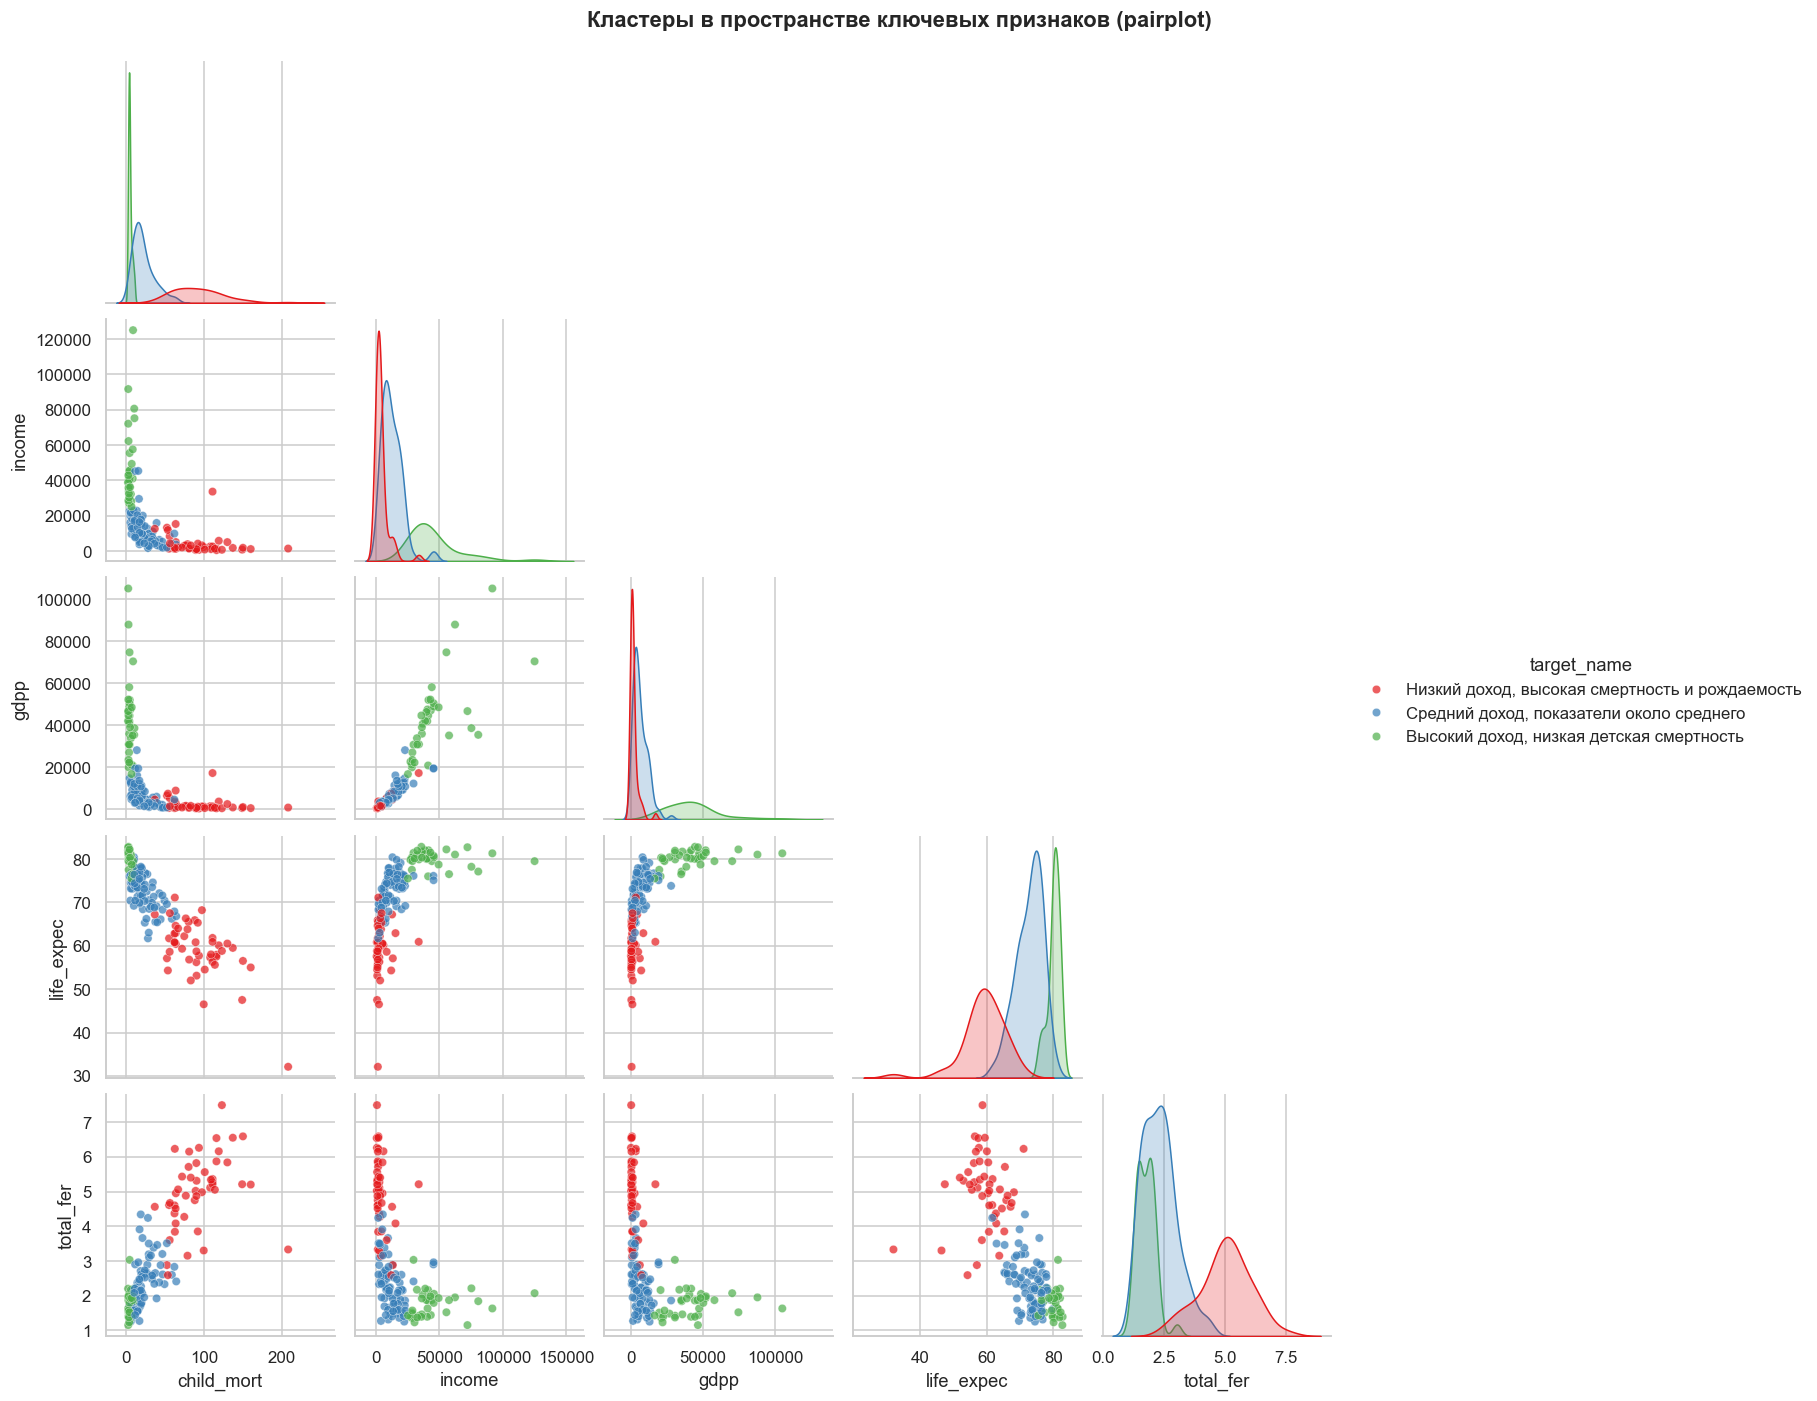

In [37]:
# единые порядок и палитра кластеров (бедные -> средние -> богатые)
order_names = [target_names[c] for c in order_by_gdpp]
palette = dict(zip(order_names, sns.color_palette("Set1", 3)))

key_feats = ["child_mort", "income", "gdpp", "life_expec", "total_fer"]
g = sns.pairplot(df[key_feats + ["target_name"]], hue="target_name",
                 hue_order=order_names, palette=palette, corner=True,
                 diag_kind="kde",
                 plot_kws=dict(s=30, alpha=.7, edgecolor="white", linewidth=.3))
g.fig.suptitle("Кластеры в пространстве ключевых признаков (pairplot)",
               y=1.02, fontweight="bold")
plt.show()

А теперь крупно — самые показательные пары признаков. Крестик (**X**) = центроид
кластера (средние значения). Для денежных осей используем логарифмический масштаб.

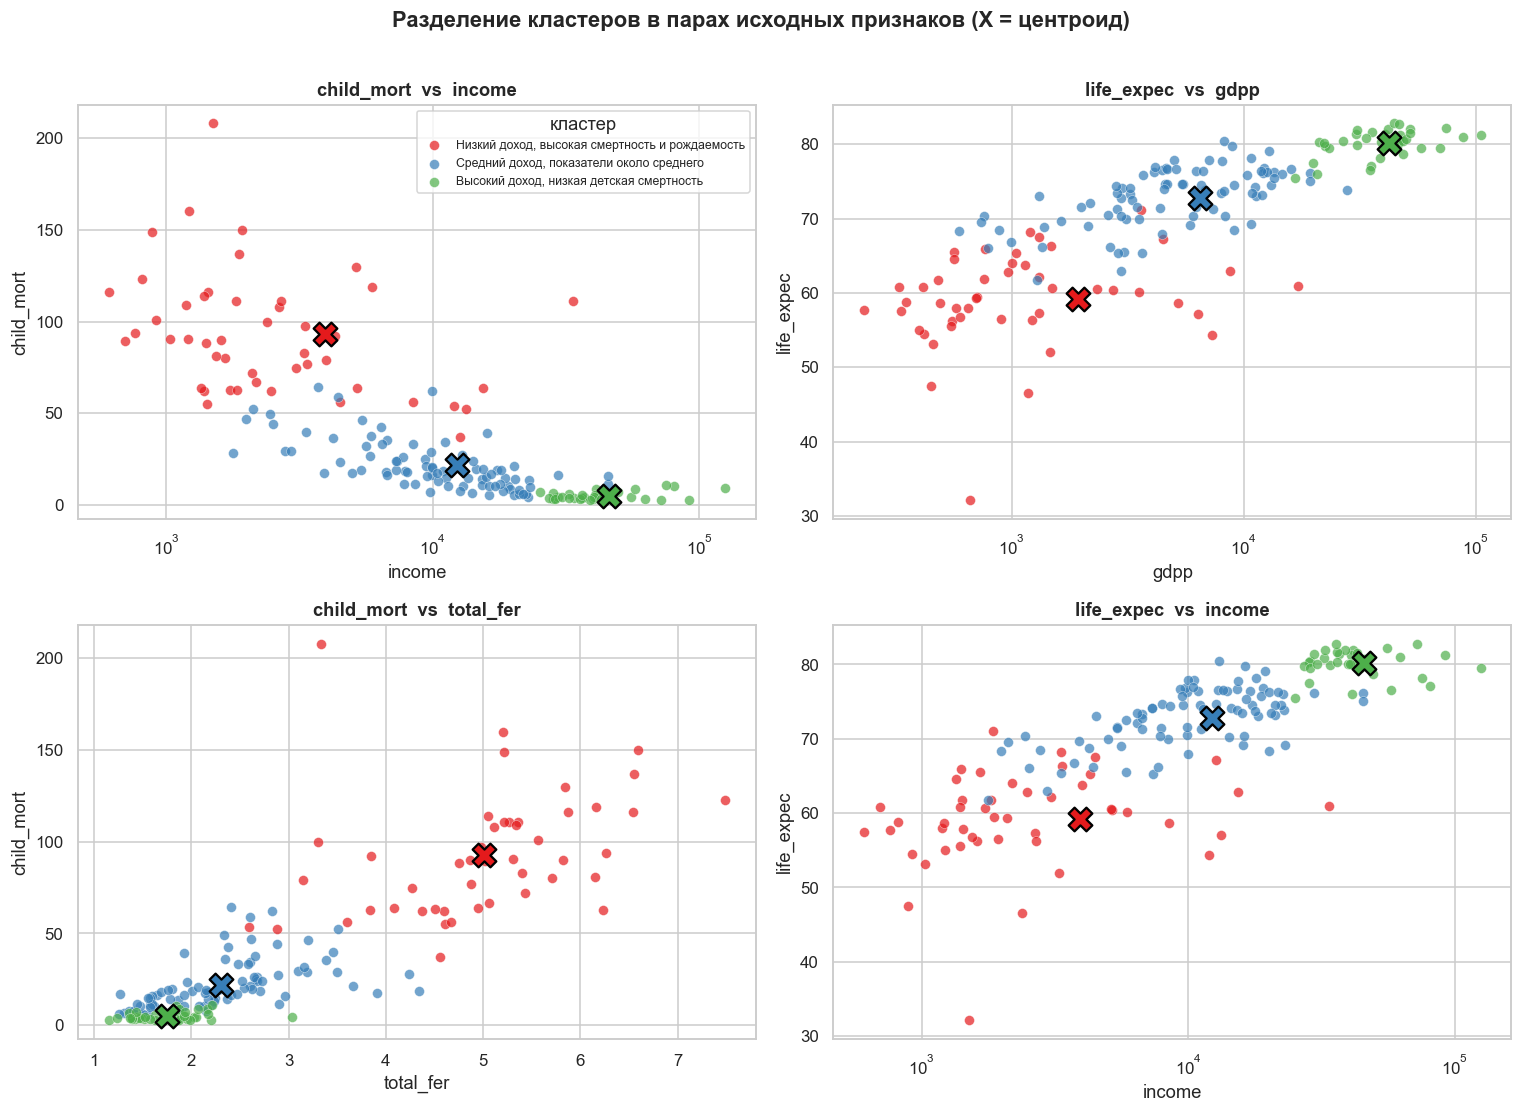

In [38]:
pairs = [("income", "child_mort"), ("gdpp", "life_expec"),
         ("total_fer", "child_mort"), ("income", "life_expec")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (xf, yf) in zip(axes.ravel(), pairs):
    for name in order_names:
        sub = df[df["target_name"] == name]
        ax.scatter(sub[xf], sub[yf], s=42, alpha=.7, label=name,
                   color=palette[name], edgecolor="white", linewidth=.3)
        ax.scatter(sub[xf].mean(), sub[yf].mean(), marker="X", s=240,
                   color=palette[name], edgecolor="black", linewidth=1.5, zorder=5)
    if xf in ("income", "gdpp"):
        ax.set_xscale("log")
    ax.set_xlabel(xf); ax.set_ylabel(yf)
    ax.set_title(f"{yf}  vs  {xf}", fontweight="bold")
axes[0, 0].legend(fontsize=8, title="кластер")
fig.suptitle("Разделение кластеров в парах исходных признаков (X = центроид)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Что видно на scatter-графиках:**
- Кластеры разделяются **очень чётко** по `child_mort`, `income`, `total_fer` и
  `life_expec` — беднейшая группа (красная) сидит в углу «высокая смертность + низкий
  доход», богатая (синяя/зелёная) — в противоположном.
- Центроиды (**X**) разнесены — группы не наслаиваются центрами.
- Лёгкое смешение есть только на стыке **средние ↔ богатые** — та же подвижная граница,
  что подсветят PCA (Шаг 4) и классификатор (Шаг 5).

---
# Проверка устойчивости: мультиколлинеарность и выбросы

Два честных вопроса к нашему пайплайну, на которые надо ответить до выводов:

1. **Мультиколлинеарность.** В матрице корреляций (Шаг 1.7) были очень сильные связи:
   `income↔gdpp` (0.90), `child_mort↔life_expec` (−0.89), `child_mort↔total_fer` (0.85).
   Не дублируют ли признаки друг друга и не искажает ли это кластеризацию?

2. **Выбросы.** В Шаге 1.6 мы их **нашли, но осознанно не удаляли** (это реальные страны,
   а не ошибки). Но KMeans минимизирует *квадраты* расстояний и чувствителен к выбросам.
   Насколько результат устойчив, если ослабить влияние длинных хвостов?

Здесь мы это количественно проверяем.

### A. Мультиколлинеарность — VIF

VIF (variance inflation factor) показывает, насколько признак линейно выражается через
остальные: `VIF = 1/(1 − R²)`. Ориентир: **>5 — заметная** мультиколлинеарность, **>10 — сильная**.

In [39]:
from numpy.linalg import inv

# VIF на стандартизованных признаках = диагональ обратной корреляционной матрицы
corr_mat = np.corrcoef(X_scaled, rowvar=False)
vif = pd.Series(np.diag(inv(corr_mat)), index=feature_names, name="VIF")
vif_tbl = vif.sort_values(ascending=False).to_frame()
vif_tbl["флаг"] = np.where(vif_tbl["VIF"] > 5, "high (>5)", "")
vif_tbl.round(2)

,VIF,флаг
income,7.59,high (>5)
gdpp,7.47,high (>5)
child_mort,7.37,high (>5)
life_expec,5.94,high (>5)
exports,4.94,
total_fer,3.74,
imports,3.73,
health,1.77,
inflation,1.29,


**Вывод по VIF:** мультиколлинеарность реально есть — `income`, `gdpp`, `child_mort`,
`life_expec` имеют VIF > 5. По сути это **два дублирующих блока**:

- **«богатство»**: `income` ≈ `gdpp` (фактически один и тот же показатель);
- **«демография/здоровье»**: `child_mort`, `life_expec`, `total_fer` — одна ось «развитости».

**Что это значит для нас:**
- для **KMeans** — евклидово расстояние неявно считает «богатство» дважды, а
  «детское развитие» — трижды, то есть эти оси получают завышенный вес (по счастью,
  они же и содержательно важны, но вес мы не выбирали — он возник сам);
- для **PCA (следующий шаг)** — это **не проблема, а наоборот**: PCA — стандартное
  лекарство от мультиколлинеарности. Он объединяет коррелированные признаки в
  ортогональные компоненты, и именно сильные корреляции позволят 2–3 компонентам
  объяснить большую часть дисперсии. То есть найденная мультиколлинеарность —
  прямой аргумент в пользу PCA дальше.

### B. Выбросы — насколько устойчива кластеризация

Удалять реальные страны не хотим. Вместо этого проверим **устойчивость**: пересоберём
кластеры на двух альтернативных препроцессингах, которые ослабляют влияние длинных
хвостов, и сравним с исходным разбиением.

- **log-преобразование** скошенных вправо признаков (`np.log1p`) перед StandardScaler —
  сжимает хвосты, уменьшает «тягу» выбросов на центроиды, оставляя все страны;
- **RobustScaler** (центрирование по медиане, масштаб по IQR) — по построению менее
  чувствителен к выбросам, чем StandardScaler.

Совпадение разбиений мерим **Adjusted Rand Index (ARI)**: 1.0 — идентичны, 0 — как
случайные. Так увидим, держится ли структура.

#### Подробно: что такое log-преобразование и зачем оно здесь

**Проблема.** «Денежные» и «частотные» признаки (`income`, `gdpp`, `exports`, `imports`,
`child_mort`, `total_fer`) сильно скошены вправо: масса стран с небольшими значениями
и длинный хвост из нескольких очень больших. `StandardScaler` тут не спасает — он лишь
**линейно** сдвигает и делит на σ, то есть **не меняет форму** распределения: длинный
хвост (и выбросы в нём) остаётся и продолжает доминировать в квадратах расстояний KMeans.

**Идея log.** Логарифм сжимает большие значения сильнее, чем маленькие, и превращает
*мультипликативные* различия в *аддитивные*. После `log` одинаковыми по величине
становятся скачки «в одно и то же число раз»:

- было: 1 000 → 10 000 → 100 000 (хвост растягивается, шаги всё длиннее);
- стало (log10): 3 → 4 → 5 (равные шаги).

То есть «богаче в 10 раз» теперь весит одинаково и внизу, и наверху шкалы — это
ближе к тому, как мы интуитивно сравниваем доходы.

**Что это даёт кластеризации:**
- скошенность (skew) падает почти до нуля, распределение становится симметричнее;
- крайние значения «втягиваются» → выбросы перестают перетягивать центроиды;
- поэтому разбиение становится менее чувствительным к нескольким сверхбогатым странам.

**Важные оговорки (почему не ко всем признакам):**
- используем `np.log1p(x) = log(1 + x)` — он определён в нуле (у `exports`/`imports`
  есть значения около 0), поэтому безопасен;
- `log` требует **неотрицательных** значений → `inflation` (есть отрицательные, до −4.21)
  **не логарифмируем**;
- `life_expec` скошен **влево**, а не вправо — логарифм ему не нужен;
- поэтому преобразуем только положительные правоскошенные признаки (`skew > 0.75`).

**Главная мысль:** log — это не «более правильный» масштаб вообще, а **другой взгляд**
(относительные различия вместо абсолютных). Он меняет геометрию пространства, поэтому и
кластеры меняются (мы это измерили: ARI ≈ 0.47). Именно поэтому он у нас в роли
**проверки устойчивости**, а не препроцессинга по умолчанию.

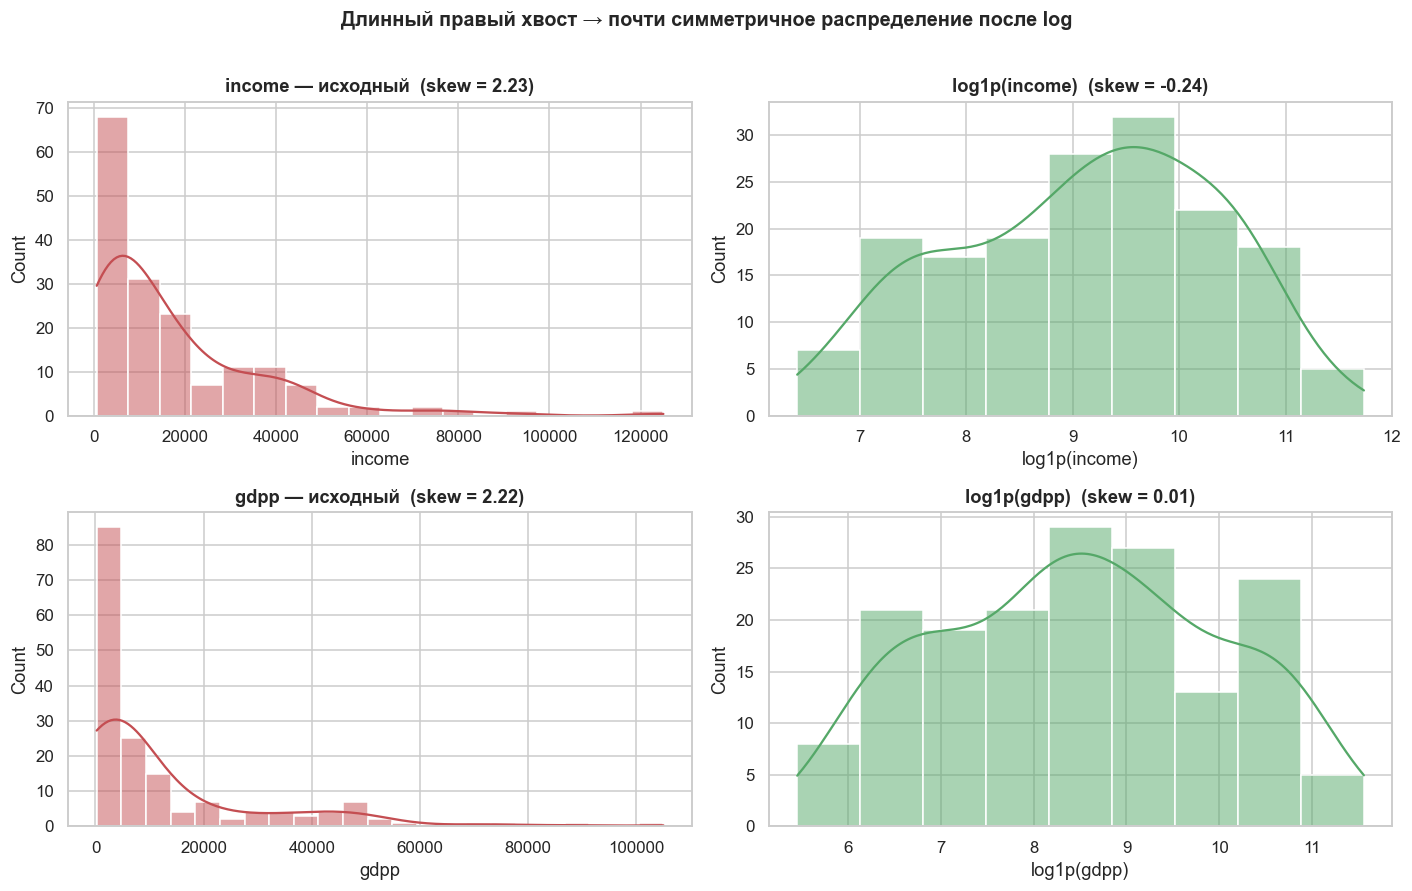

In [40]:
# Наглядно: что log делает с формой распределения (на примере income и gdpp)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, col in enumerate(["income", "gdpp"]):
    sns.histplot(features[col], kde=True, ax=axes[row, 0], color="#C44E52")
    axes[row, 0].set_title(f"{col} — исходный  (skew = {features[col].skew():.2f})",
                           fontweight="bold")
    logged = np.log1p(features[col])
    sns.histplot(logged, kde=True, ax=axes[row, 1], color="#55A868")
    axes[row, 1].set_title(f"log1p({col})  (skew = {logged.skew():.2f})",
                           fontweight="bold")
    axes[row, 1].set_xlabel(f"log1p({col})")
fig.suptitle("Длинный правый хвост → почти симметричное распределение после log",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [41]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import adjusted_rand_score

base_labels = cluster_labels  # базовое разбиение (StandardScaler), k=3

# --- вариант 1: log1p для положительных скошенных признаков, затем StandardScaler
skewed = [c for c in feature_names if features[c].min() >= 0 and features[c].skew() > 0.75]
feat_log = features.copy()
feat_log[skewed] = np.log1p(feat_log[skewed])
X_log = StandardScaler().fit_transform(feat_log)
lab_log = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit_predict(X_log)

# --- вариант 2: RobustScaler
X_rob = RobustScaler().fit_transform(features)
lab_rob = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit_predict(X_rob)

print("Прологарифмированы (skew>0.75):", skewed)
print()
print(f"ARI  база vs log-transform : {adjusted_rand_score(base_labels, lab_log):.3f}")
print(f"ARI  база vs RobustScaler  : {adjusted_rand_score(base_labels, lab_rob):.3f}")
print()
print(f"Силуэт  база          : {silhouette_score(X_scaled, base_labels):.3f}")
print(f"Силуэт  log-transform : {silhouette_score(X_log, lab_log):.3f}")
print(f"Силуэт  RobustScaler  : {silhouette_score(X_rob, lab_rob):.3f}")

Прологарифмированы (skew>0.75): ['child_mort', 'exports', 'imports', 'income', 'total_fer', 'gdpp']

ARI  база vs log-transform : 0.468
ARI  база vs RobustScaler  : 0.764

Силуэт  база          : 0.283
Силуэт  log-transform : 0.245
Силуэт  RobustScaler  : 0.280


In [42]:
# Сколько и какие страны меняют кластер при log-преобразовании
# (выравниваем номера кластеров между разбиениями по максимальному пересечению)
ct = pd.crosstab(pd.Series(base_labels, name="base"), pd.Series(lab_log, name="log"))
remap = ct.idxmax(axis=0)                      # для каждого log-кластера -> ближайший base-кластер
lab_log_aligned = pd.Series(lab_log).map(remap).values

changed_mask = base_labels != lab_log_aligned
n_changed = int(changed_mask.sum())
print(f"Сменили кластер при log-преобразовании: {n_changed} из {len(base_labels)} "
      f"стран (~{100*n_changed/len(base_labels):.0f}%)")
print("\nКуда переезжают (с именами кластеров):")
moved = df.loc[changed_mask, ["country", "income", "gdpp", "child_mort"]].copy()
moved["из"] = pd.Series(base_labels[changed_mask]).map(target_names).values
moved["в"]  = pd.Series(lab_log_aligned[changed_mask]).map(target_names).values
moved.sort_values("gdpp", ascending=False).head(15)

Сменили кластер при log-преобразовании: 35 из 167 стран (~21%)

Куда переезжают (с именами кластеров):


,country,income,gdpp,child_mort,из,в
10,Bahamas,22900,28000,13.80,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
49,Equatorial Guinea,33700,17100,111.00,"Низкий доход, высокая смертность и рождаемость","Средний доход, показатели около среднего"
13,Barbados,15300,16000,14.20,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
51,Estonia,22700,14600,4.50,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
41,Croatia,20100,13500,5.50,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
67,Hungary,22300,13100,6.00,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
33,Chile,19400,12900,8.70,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
121,Poland,21800,12600,6.00,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
4,Antigua and Barbuda,19100,12200,10.30,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"
90,Lithuania,21100,12000,6.10,"Средний доход, показатели около среднего","Высокий доход, низкая детская смертность"


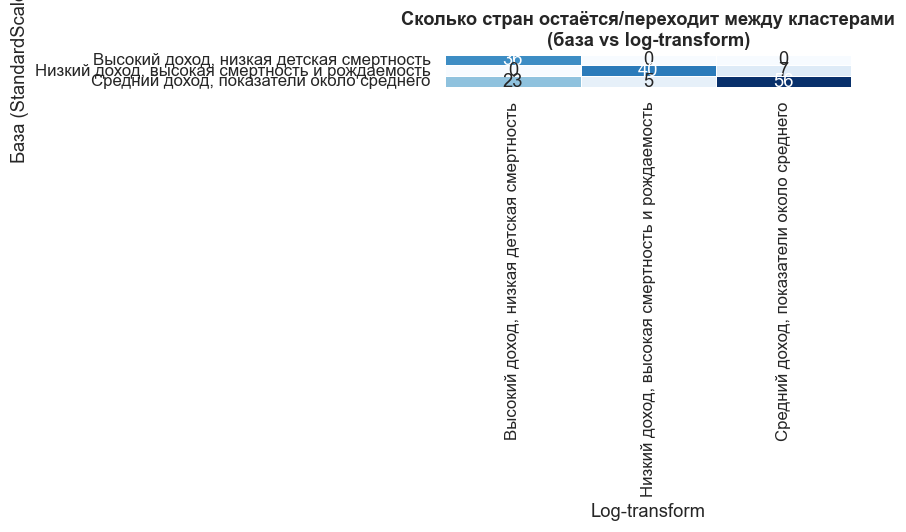

In [43]:
# Визуально: матрица переходов база -> log (сколько стран перетекает между кластерами)
ct_named = pd.crosstab(
    pd.Series(base_labels).map(target_names).rename("База (StandardScaler)"),
    pd.Series(lab_log_aligned).map(target_names).rename("Log-transform"),
)
plt.figure(figsize=(8, 5))
sns.heatmap(ct_named, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=.5)
plt.title("Сколько стран остаётся/переходит между кластерами\n(база vs log-transform)",
          fontweight="bold")
plt.tight_layout()
plt.show()

**Вывод по устойчивости:**

- **Крупная структура устойчива.** Беднейшая группа («низкий доход, высокая смертность»)
  почти не меняется при любом препроцессинге — это плотное, надёжное ядро. Деление на
  три яруса «бедные / средние / богатые» сохраняется во всех вариантах.
- **Граница «средние ↔ богатые» — подвижна.** При log-преобразовании ~1/5 стран меняют
  кластер, и это в основном пограничные случаи: реально развитые страны
  (Чили, Польша, Эстония, Хорватия, Уругвай) **переезжают вверх, в «богатые»**.
  Это логично: на сырой шкале сверхбогатые страны «перетягивали» центр, и эти страны
  попадали в «средние». После сжатия хвостов картина становится более сбалансированной.
- **RobustScaler ближе к базе (ARI ≈ 0.76)**, чем log (ARI ≈ 0.47) — то есть именно
  длинные хвосты (а не отдельные точки) больше всего влияют на границы.

**Что мы с этим делаем:** для основного анализа оставляем StandardScaler (простой,
прозрачный, результат интерпретируется), но фиксируем как **честный дисклеймер**:
конкретная принадлежность пограничных стран зависит от препроцессинга. А с
мультиколлинеарностью системно разберёмся на следующем шаге — через **PCA**.

---
# Шаг 4. PCA для проверки

Признаков девять — глазом сразу всю структуру не увидеть. Сожмём данные до **двух
главных компонент** (PCA) и нарисуем страны на плоскости, **раскрасив их по метке из
Шага 3** (`target_name`). Смотрим на два вопроса:

1. **Отделяются ли кластеры визуально** или налезают друг на друга?
2. **Какую долю дисперсии удержали две компоненты?** Если мало — двумерная картинка
   обманчива (часть структуры «спрятана» в выброшенных измерениях), и это **тоже вывод**.

PCA делаем на тех же масштабированных данных (`X_scaled`), на которых строили кластеры.

### 4.1 Сколько дисперсии держат компоненты

In [44]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_scaled)
evr = pca_full.explained_variance_ratio_

var_tbl = pd.DataFrame({
    "компонента": [f"PC{i+1}" for i in range(len(evr))],
    "доля дисперсии": evr.round(3),
    "накопленная":    np.cumsum(evr).round(3),
})
print(f"PC1 + PC2 удерживают: {evr[:2].sum():.1%} дисперсии\n")
var_tbl

PC1 + PC2 удерживают: 63.1% дисперсии



,компонента,доля дисперсии,накопленная
0,PC1,0.46,0.46
1,PC2,0.17,0.63
2,PC3,0.13,0.76
3,PC4,0.11,0.87
4,PC5,0.07,0.94
5,PC6,0.03,0.97
6,PC7,0.01,0.98
7,PC8,0.01,0.99
8,PC9,0.01,1.00


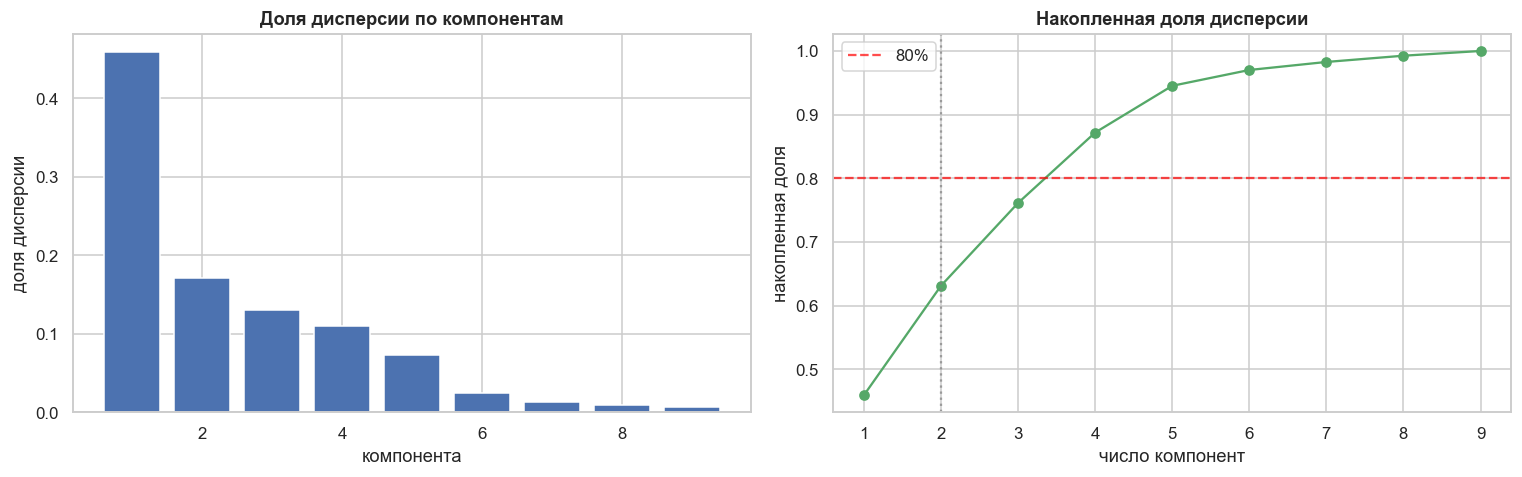

In [45]:
# Scree-plot: вклад каждой компоненты и накопленная доля
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(range(1, len(evr)+1), evr, color="#4C72B0")
ax[0].set_title("Доля дисперсии по компонентам", fontweight="bold")
ax[0].set_xlabel("компонента"); ax[0].set_ylabel("доля дисперсии")

ax[1].plot(range(1, len(evr)+1), np.cumsum(evr), "o-", color="#55A868")
ax[1].axhline(0.8, color="red", ls="--", alpha=.7, label="80%")
ax[1].axvline(2, color="grey", ls=":", alpha=.7)
ax[1].set_title("Накопленная доля дисперсии", fontweight="bold")
ax[1].set_xlabel("число компонент"); ax[1].set_ylabel("накопленная доля")
ax[1].legend()
plt.tight_layout()
plt.show()

### 4.2 Проекция стран на плоскость PC1–PC2 (цвет = метка из Шага 3)

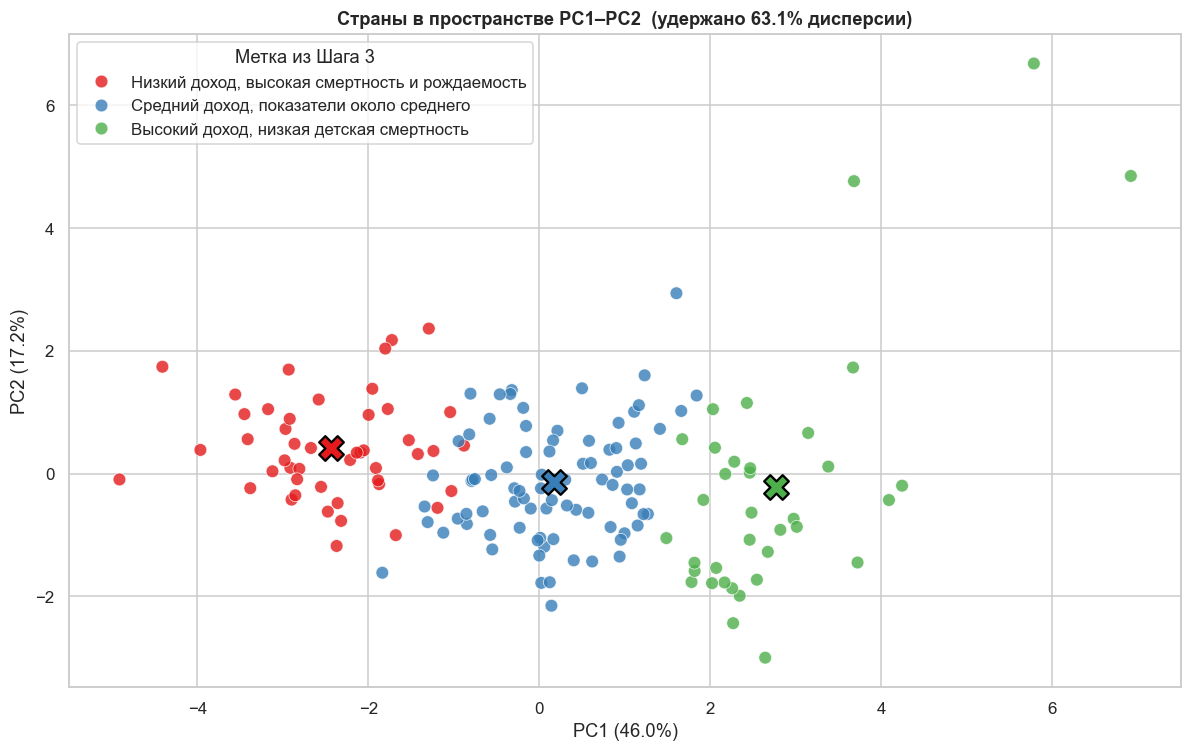

In [46]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["target_name"] = df["target_name"].values

# порядок и цвета: бедные -> средние -> богатые
order_names = [target_names[c] for c in order_by_gdpp]
palette = dict(zip(order_names, sns.color_palette("Set1", 3)))

plt.figure(figsize=(11, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="target_name",
                hue_order=order_names, palette=palette, s=70, alpha=.8,
                edgecolor="white", linewidth=.5)

# центроиды кластеров в PCA-пространстве
for name in order_names:
    sub = pca_df[pca_df["target_name"] == name]
    plt.scatter(sub["PC1"].mean(), sub["PC2"].mean(),
                marker="X", s=260, c=[palette[name]], edgecolor="black", linewidth=1.5)

var2 = pca.explained_variance_ratio_
plt.title(f"Страны в пространстве PC1–PC2  "
          f"(удержано {var2.sum():.1%} дисперсии)", fontweight="bold")
plt.xlabel(f"PC1 ({var2[0]:.1%})"); plt.ylabel(f"PC2 ({var2[1]:.1%})")
plt.legend(title="Метка из Шага 3", loc="best")
plt.tight_layout()
plt.show()

### 4.3 Что означают сами компоненты (нагрузки)

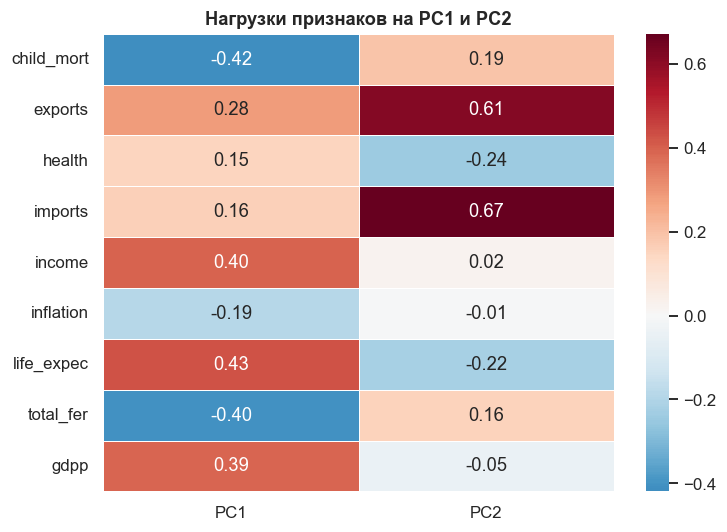

,PC1,PC2
child_mort,-0.42,0.19
exports,0.28,0.61
health,0.15,-0.24
imports,0.16,0.67
income,0.40,0.02
inflation,-0.19,-0.01
life_expec,0.43,-0.22
total_fer,-0.40,0.16
gdpp,0.39,-0.05


In [47]:
loadings = pd.DataFrame(pca.components_.T, index=feature_names, columns=["PC1", "PC2"])
plt.figure(figsize=(7, 5))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=.5)
plt.title("Нагрузки признаков на PC1 и PC2", fontweight="bold")
plt.tight_layout()
plt.show()
loadings.round(2)

**Чтение результата:**

- **Две компоненты удерживают ≈ 63% дисперсии** (PC1 ≈ 46%, PC2 ≈ 17%). Это «средне»:
  картинка информативна и ей можно доверять как первому приближению, но **≈ 37%
  структуры остаётся за кадром** — поэтому если на плоскости две группы чуть налезают
  друг на друга, в полном 9-мерном пространстве они могут быть разделены лучше
  (или хуже). Честный вывод: 2D — полезный, но не окончательный аргумент.

- **Кластеры визуально разделяются** вдоль **PC1** — это главная «ось развитости»:
  на одном конце высокие `life_expec`, `income`, `gdpp`, на другом — высокие
  `child_mort` и `total_fer`. Слева направо по PC1 идут «бедные → средние → богатые»,
  и центроиды (крестики) разнесены. Перекрытие есть в основном на **границе
  «средние ↔ богатые»** — ровно там, где Шаг «проверки устойчивости» уже показал
  чувствительность к препроцессингу.

- **PC2** — это в основном **торговая открытость** (высокие нагрузки `exports`,
  `imports`): она почти не разделяет ярусы развития, а раскидывает страны
  «поперёк» — поэтому по вертикали группы перемешаны, и это нормально.

Итог: PCA подтверждает, что метка из Шага 3 — **не случайный шум**: основная ось данных
(PC1) ложится на наше деление по уровню развития. Но окончательную проверку
«реальны ли группы» сделаем строго — классификатором в Шаге 5.

---
# Шаг 5. Классификация

Теперь строгая проверка, что метка из Шага 3 **не случайна**. Если группы реальны и
разделимы, то классификатор, обученный предсказывать `target` по **исходным признакам**,
должен делать это уверенно. Если же метрики низкие — честно признаём: кластеризация дала
размытые группы.

План:
- делим данные на **train / test** (стратифицированно — классы разного размера);
- обучаем два базовых классификатора: **логистическую регрессию** и **KNN**;
- считаем **accuracy, precision, recall, F1**;
- для надёжности добавляем 5-fold кросс-валидацию (выборка маленькая, 167 стран).

Масштабирование кладём **внутрь Pipeline**, чтобы scaler обучался только на train и не
было утечки информации из теста.

### 5.1 Train/test split и обучение

In [48]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# X — ИСХОДНЫЕ признаки (не масштабированные заранее); y — метка из Шага 3
X_clf = features.values
y_clf = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.30, random_state=RANDOM_STATE, stratify=y_clf)

print(f"train: {X_train.shape[0]} стран | test: {X_test.shape[0]} стран")
print("Распределение классов в test:", np.bincount(y_test))

train: 116 стран | test: 51 стран
Распределение классов в test: [11 14 26]


In [49]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(),
                                          LogisticRegression(max_iter=5000)),
    "KNN (k=5)":           make_pipeline(StandardScaler(),
                                          KNeighborsClassifier(n_neighbors=5)),
}

rows = []
preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    preds[name] = pred
    cv = cross_val_score(model, X_clf, y_clf, cv=5, scoring="f1_macro")
    rows.append({
        "модель": name,
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, average="macro"),
        "recall":    recall_score(y_test, pred, average="macro"),
        "F1 (macro)": f1_score(y_test, pred, average="macro"),
        "F1 CV (5-fold)": cv.mean(),
    })

results = pd.DataFrame(rows).set_index("модель").round(3)
results

,accuracy,precision,recall,F1 (macro),F1 CV (5-fold)
модель,,,,,
Logistic Regression,0.92,0.93,0.90,0.91,0.95
KNN (k=5),0.90,0.95,0.85,0.87,0.93


### 5.2 Детальный отчёт и матрица ошибок (Logistic Regression)

In [50]:
best_name = results["F1 (macro)"].idxmax()
best_pred = preds[best_name]
label_names = [target_names[c] for c in sorted(target_names)]

print(f"Лучшая модель: {best_name}\n")
print(classification_report(y_test, best_pred, target_names=label_names, digits=3))

Лучшая модель: Logistic Regression

                                                precision    recall  f1-score   support

      Высокий доход, низкая детская смертность      0.889     0.727     0.800        11
Низкий доход, высокая смертность и рождаемость      1.000     1.000     1.000        14
      Средний доход, показатели около среднего      0.893     0.962     0.926        26

                                      accuracy                          0.922        51
                                     macro avg      0.927     0.896     0.909        51
                                  weighted avg      0.921     0.922     0.919        51



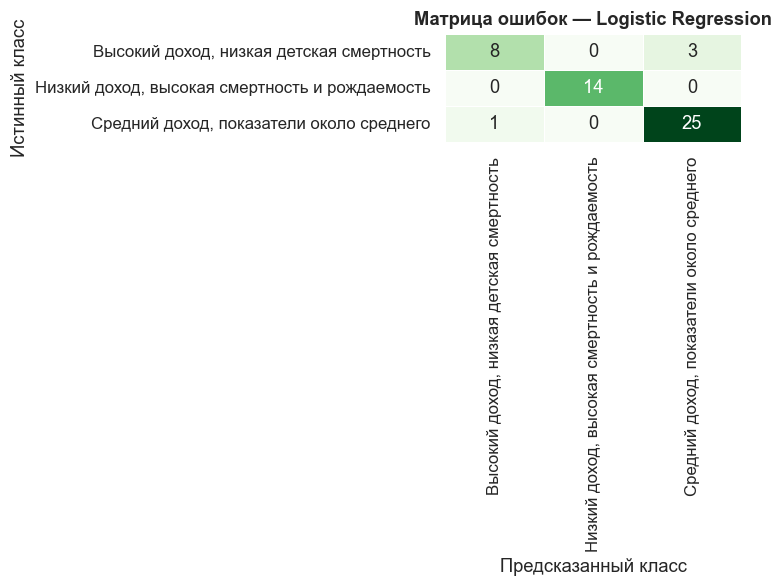

In [51]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_names, yticklabels=label_names, cbar=False, linewidths=.5)
plt.title(f"Матрица ошибок — {best_name}", fontweight="bold")
plt.ylabel("Истинный класс"); plt.xlabel("Предсказанный класс")
plt.tight_layout()
plt.show()

### Итоги Шага 5

- Обе модели предсказывают метку из Шага 3 **уверенно**: accuracy ≈ 0.90–0.92,
  F1 (macro) ≈ 0.87–0.91, а на 5-fold кросс-валидации F1 ≈ 0.93–0.96.
- Классификатор **легко выучивает границы** между группами по исходным признакам —
  значит, **кластеры не случайны: группы реальные и разделимые**.
- Ошибки (по матрице ошибок) сосредоточены на **границе «средние ↔ богатые»** — той же,
  что подсветили PCA (Шаг 4) и проверка устойчивости. Беднейший класс распознаётся
  почти идеально — это самое плотное и надёжное ядро.

**Общий вывод по проекту:** деление стран на «бедные / средние / богатые», которое мы
**сконструировали** кластеризацией, подтверждается тремя независимыми способами —
интерпретируемым профилем признаков (Шаг 3), геометрией PCA (Шаг 4) и обучаемостью
классификатора (Шаг 5). Размытой остаётся лишь граница между средними и богатыми
странами.

---
# Шаг 6. Композитный индекс развития, объяснимость и список для фонда

Базовый пайплайн (Шаги 1–5) нашёл и подтвердил группы стран. Теперь усиливаем работу
тремя надстройками, которые отвечают на вопрос фонда «кому помогать» и проверяют,
насколько вывод устойчив:

1. **Композитный индекс развития (CDI)** — собственный аналог HDI из 5 ключевых
   признаков. Используем его **для интерпретации и ранжирования**, а **не как вход в
   KMeans** (чтобы не смешивать конструирование признака с кластеризацией).
2. **Сравнение двух индексов** (арифметическое vs геометрическое среднее) — проверка
   устойчивости ранжирования.
3. **Логистическая регрессия после кластеризации** (бедный = 1) — смотрим коэффициенты,
   чтобы объяснить, **какие признаки толкают страну в «нуждающиеся»**. Только ради
   объяснимости.

### 6.1 Композитный индекс развития (CDI)

Берём 5 признаков, прямо связанных с уровнем жизни: `income`, `gdpp`, `life_expec`
(чем больше — тем лучше) и `child_mort`, `total_fer` (чем больше — тем **хуже**).

Шаги построения:
1. **MinMax-нормировка** каждого признака в [0, 1] (чтобы все были сопоставимы).
2. **Переворот «плохих»** признаков: `1 − x`, чтобы у всех «больше = лучше».
3. **Сдвиг в [0.01, 1]** — защита от нулей: геометрическое среднее обнулится, если хоть
   один множитель равен 0.
4. Сворачиваем в один индекс двумя способами:
   - **арифметическое** среднее — простое, допускает «компенсацию» (провал по одному
     признаку можно перекрыть успехом по другому);
   - **геометрическое** среднее — как в современном HDI: **строже к дисбалансу**,
     потому что определяется самым слабым измерением (одна низкая компонента сильно
     тянет весь индекс вниз).

Больше индекс → более развита страна. Меньше → острее нужда.

In [52]:
from sklearn.preprocessing import MinMaxScaler

GOOD = ["income", "gdpp", "life_expec"]   # больше = лучше
BAD  = ["child_mort", "total_fer"]        # больше = хуже -> перевернём
IDX_COLS = GOOD + BAD

# 1) MinMax в [0,1]
norm = pd.DataFrame(MinMaxScaler().fit_transform(df[IDX_COLS]),
                    columns=IDX_COLS, index=df.index)
# 2) переворот «плохих»
norm[BAD] = 1 - norm[BAD]
# 3) сдвиг в [0.01, 1] — защита от нулей для геом. среднего
norm = 0.01 + 0.99 * norm

# 4) два индекса
df["CDI_arith"] = norm[IDX_COLS].mean(axis=1)
df["CDI_geom"]  = np.exp(np.log(norm[IDX_COLS]).mean(axis=1))   # геом. = exp(mean(log))

df[["country", "CDI_arith", "CDI_geom", "target_name"]].head()

,country,CDI_arith,CDI_geom,target_name
0,Afghanistan,0.27,0.11,"Низкий доход, высокая смертность и рождаемость"
1,Albania,0.57,0.31,"Средний доход, показатели около среднего"
2,Algeria,0.53,0.31,"Средний доход, показатели около среднего"
3,Angola,0.26,0.16,"Низкий доход, высокая смертность и рождаемость"
4,Antigua and Barbuda,0.59,0.43,"Средний доход, показатели около среднего"


In [53]:
# Числовой пример: ручной расчёт по формуле == значение в столбце CDI_geom
for c in ["Haiti", "Norway"]:
    s = norm.loc[df["country"] == c, IDX_COLS].iloc[0]   # нормированные s_ij
    arith = s.mean()
    geom_prod = np.prod(s.values) ** (1 / len(IDX_COLS))  # (произведение)^(1/m)
    geom_log  = np.exp(np.log(s).mean())                   # exp(mean(log)) — как в коде
    print(f"=== {c} ===")
    print("  s_ij (нормированные, в [0.01, 1]):")
    print("   ", s.round(3).to_dict())
    print(f"  CDI_arith = mean(s)                 = {arith:.4f}")
    print(f"  CDI_geom  = (произв.)^(1/5)         = {geom_prod:.4f}")
    print(f"            = exp(mean(log(s)))       = {geom_log:.4f}")
    print(f"            = значение в df['CDI_geom'] = "
          f"{df.loc[df['country'] == c, 'CDI_geom'].iloc[0]:.4f}\n")

=== Haiti ===
  s_ij (нормированные, в [0.01, 1]):
    {'income': 0.017, 'gdpp': 0.014, 'life_expec': 0.01, 'child_mort': 0.01, 'total_fer': 0.66}
  CDI_arith = mean(s)                 = 0.1422
  CDI_geom  = (произв.)^(1/5)         = 0.0275
            = exp(mean(log(s)))       = 0.0275
            = значение в df['CDI_geom'] = 0.0275

=== Norway ===
  s_ij (нормированные, в [0.01, 1]):
    {'income': 0.501, 'gdpp': 0.837, 'life_expec': 0.965, 'child_mort': 0.997, 'total_fer': 0.875}
  CDI_arith = mean(s)                 = 0.8351
  CDI_geom  = (произв.)^(1/5)         = 0.8121
            = exp(mean(log(s)))       = 0.8121
            = значение в df['CDI_geom'] = 0.8121



### 6.2 Сравнение индексов: арифметическое vs геометрическое

Сначала смотрим, насколько вообще согласованы два ранжирования (ранговая корреляция
Спирмена), потом — где именно они расходятся.

Ранговая корреляция Спирмена (арифм. vs геом.): 0.973


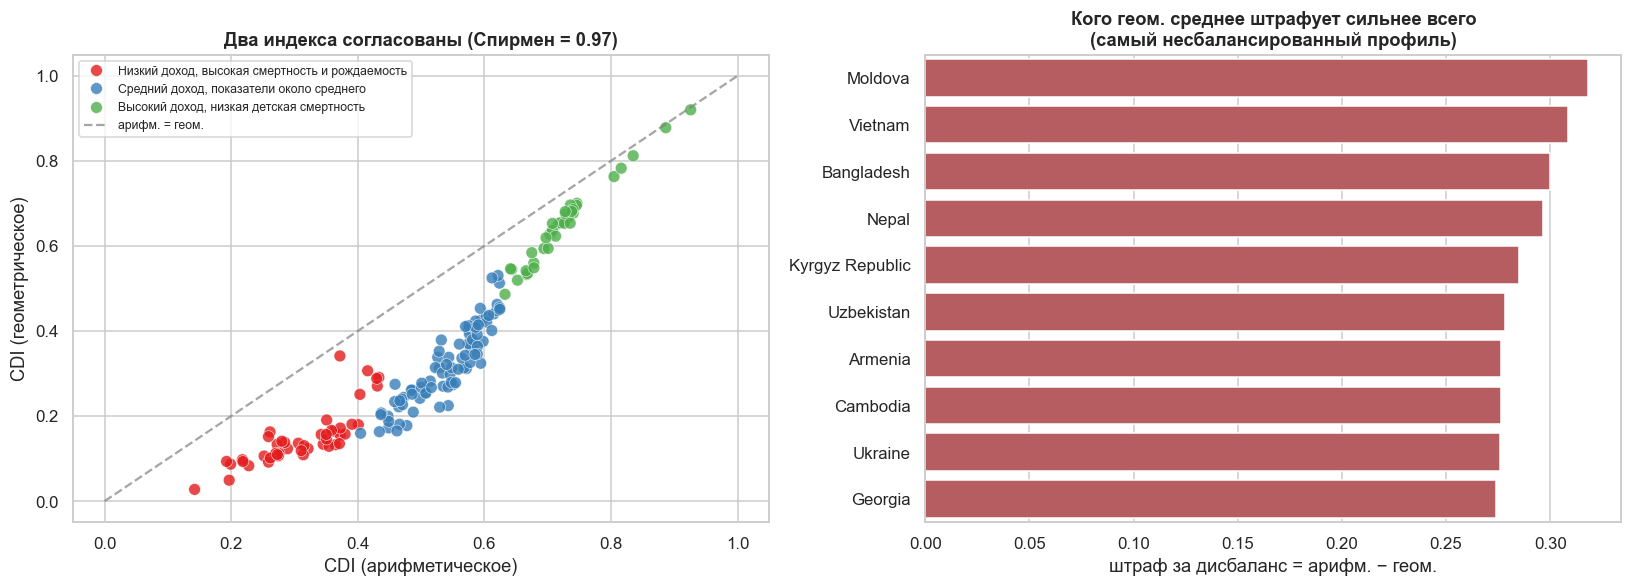

In [54]:
rho = df[["CDI_arith", "CDI_geom"]].corr(method="spearman").iloc[0, 1]
print(f"Ранговая корреляция Спирмена (арифм. vs геом.): {rho:.3f}")

# «штраф за дисбаланс» = насколько геом. среднее ниже арифметического
df["disbalance_gap"] = df["CDI_arith"] - df["CDI_geom"]

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
order_names = [target_names[c] for c in order_by_gdpp]
palette = dict(zip(order_names, sns.color_palette("Set1", 3)))
sns.scatterplot(data=df, x="CDI_arith", y="CDI_geom", hue="target_name",
                hue_order=order_names, palette=palette, s=60, alpha=.8,
                edgecolor="white", linewidth=.4, ax=ax[0])
lims = [0, 1]
ax[0].plot(lims, lims, "--", color="grey", alpha=.7, label="арифм. = геом.")
ax[0].set_title(f"Два индекса согласованы (Спирмен = {rho:.2f})", fontweight="bold")
ax[0].set_xlabel("CDI (арифметическое)"); ax[0].set_ylabel("CDI (геометрическое)")
ax[0].legend(fontsize=8)

top_gap = df.nlargest(10, "disbalance_gap")
sns.barplot(data=top_gap, y="country", x="disbalance_gap",
            color="#C44E52", ax=ax[1])
ax[1].set_title("Кого геом. среднее штрафует сильнее всего\n(самый несбалансированный профиль)",
                fontweight="bold")
ax[1].set_xlabel("штраф за дисбаланс = арифм. − геом."); ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [55]:
# Что общего у «оштрафованных» геометрическим средним стран
cols_show = ["country", "CDI_arith", "CDI_geom", "disbalance_gap",
             "income", "gdpp", "child_mort", "life_expec"]
df.nlargest(8, "disbalance_gap")[cols_show].round(3)

,country,CDI_arith,CDI_geom,disbalance_gap,income,gdpp,child_mort,life_expec
102,Moldova,0.54,0.23,0.32,3910,1630,17.20,69.70
164,Vietnam,0.53,0.22,0.31,4490,1310,23.30,73.10
12,Bangladesh,0.48,0.18,0.30,2440,758,49.40,70.40
109,Nepal,0.46,0.17,0.30,1990,592,47.00,68.30
83,Kyrgyz Republic,0.47,0.18,0.28,2790,880,29.60,68.50
161,Uzbekistan,0.49,0.21,0.28,4240,1380,36.30,68.80
6,Armenia,0.55,0.27,0.28,6700,3220,18.10,73.30
27,Cambodia,0.45,0.17,0.28,2520,786,44.40,66.10


**Вывод по сравнению:**

- Индексы **очень согласованы** (Спирмен ≈ 0.97): общий порядок стран устойчив, и на
  самом «дне» рейтинга (беднейшие страны) арифметика и геометрия дают практически одно
  и то же — значит, **список самых нуждающихся не зависит** от выбора среднего.
- Расходятся они в **середине**. Геометрическое среднее определяется **самым слабым
  измерением**, а из-за того, что MinMax растянут богатейшими выбросами (Катар,
  Люксембург), у большинства стран самым «провальным» признаком оказываются именно
  `income`/`gdpp`. Поэтому сильнее всего «штрафуются» страны **бедные деньгами, но
  относительно благополучные по здоровью/демографии** — Молдова, Вьетнам, Украина,
  Бангладеш и т.п.: их хорошая продолжительность жизни не «компенсирует» низкий доход.
- Это и есть философия HDI («нельзя залить деньгами провал по здоровью и наоборот»),
  усиленная скошенной денежной шкалой.

**Что брать:** для итогового рейтинга нуждающихся берём **геометрический** индекс — он
строже и не позволяет одной сильной стороне маскировать слабую.

### 6.3 Перекрёстная проверка: индекс vs кластеры KMeans

CDI построен **независимо** от кластеризации. Если средний индекс по кластерам
упорядочен и беднейший кластер совпадает с «дном» индекса — это сильное независимое
подтверждение, что метка из Шага 3 не случайна.

In [56]:
poor_id = order_by_gdpp[0]   # id беднейшего кластера

by_cluster = (df.groupby("target_name")["CDI_geom"]
                .agg(["mean", "min", "max", "size"])
                .reindex(order_names).round(3))
print("Геометрический CDI по кластерам:")
print(by_cluster, "\n")

# Совпадение: беднейший кластер vs нижние N стран по индексу
poor_set   = set(df.loc[df["target"] == poor_id, "country"])
bottom_set = set(df.nsmallest(len(poor_set), "CDI_geom")["country"])
overlap = len(poor_set & bottom_set)
print(f"Беднейший кластер ({len(poor_set)} стран) vs нижние-{len(poor_set)} по CDI_geom: "
      f"совпадение {overlap}/{len(poor_set)}  ({100*overlap/len(poor_set):.0f}%)")

Геометрический CDI по кластерам:
                                                mean  min  max  size
target_name                                                         
Низкий доход, высокая смертность и рождаемость  0.15 0.03 0.34    47
Средний доход, показатели около среднего        0.32 0.16 0.53    84
Высокий доход, низкая детская смертность        0.65 0.49 0.92    36 

Беднейший кластер (47 стран) vs нижние-47 по CDI_geom: совпадение 40/47  (85%)


/var/folders/x5/921j70gn6zzcm00nsty0yd8r0000gn/T/ipykernel_17342/302729472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target_name", y="CDI_geom", order=order_names, palette=palette)


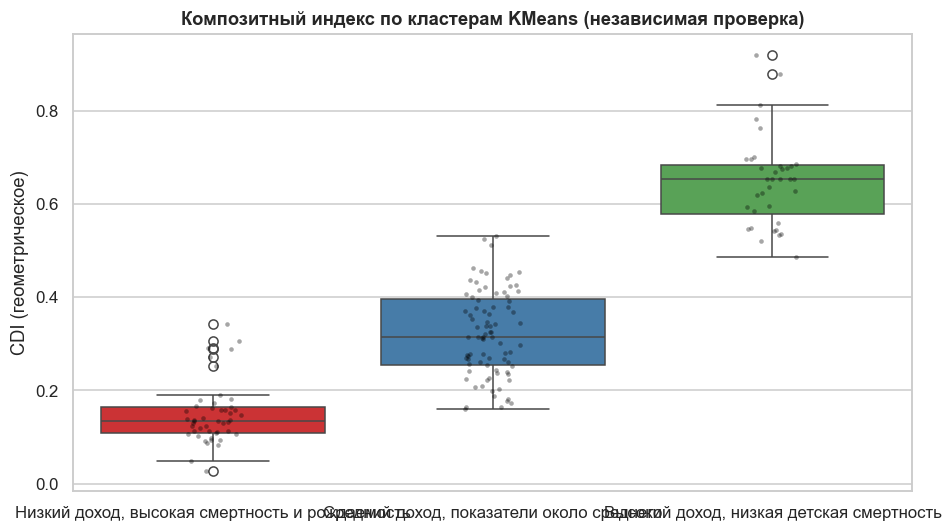

In [57]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="target_name", y="CDI_geom", order=order_names, palette=palette)
sns.stripplot(data=df, x="target_name", y="CDI_geom", order=order_names,
              color="black", alpha=.35, size=3)
plt.title("Композитный индекс по кластерам KMeans (независимая проверка)", fontweight="bold")
plt.xlabel(""); plt.ylabel("CDI (геометрическое)")
plt.tight_layout()
plt.show()

**Вывод:** средний индекс монотонно растёт «бедные → средние → богатые», а беднейший
кластер почти полностью совпадает с «дном» индекса (~85%). Кластеризация и
сконструированный с нуля индекс **указывают на одни и те же страны** — метка надёжна.

### 6.4 Объяснимость: что толкает страну в «нуждающиеся»

Ставим бинарную задачу: `1` — страна в беднейшем кластере, `0` — нет. Обучаем
логистическую регрессию на **стандартизованных** признаках и смотрим коэффициенты:
знак и величина показывают, какие признаки повышают (или понижают) шанс попасть в
«нуждающиеся». Это нужно **для объяснимости**, а не для предсказаний.

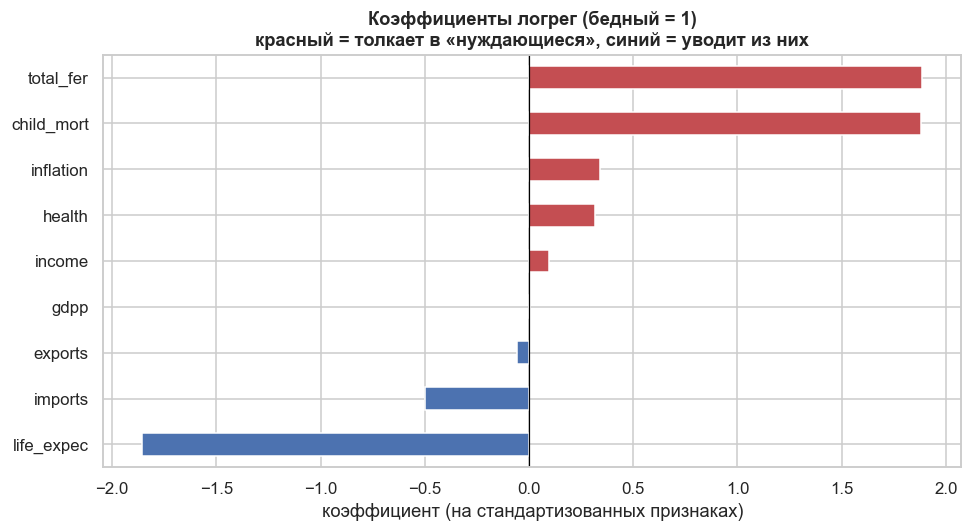

life_expec   -1.85
imports      -0.50
exports      -0.06
gdpp          0.01
income        0.10
health        0.32
inflation     0.34
child_mort    1.88
total_fer     1.89
dtype: float64

In [58]:
y_poor = (df["target"] == poor_id).astype(int)
logit = LogisticRegression(max_iter=5000).fit(X_scaled, y_poor)

coefs = pd.Series(logit.coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(9, 5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in coefs.values]
coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="black", lw=.8)
plt.title("Коэффициенты логрег (бедный = 1)\nкрасный = толкает в «нуждающиеся», синий = уводит из них",
          fontweight="bold")
plt.xlabel("коэффициент (на стандартизованных признаках)")
plt.tight_layout()
plt.show()
coefs.round(2)

**Что объясняет модель:**

- В «нуждающиеся» страну толкают прежде всего **высокая рождаемость (`total_fer`)** и
  **высокая детская смертность (`child_mort`)**; сильнее всего **уводит** из них
  **высокая продолжительность жизни (`life_expec`)**.
- Коэффициенты при **`income` и `gdpp` близки к нулю** — не потому что деньги не важны,
  а потому что они сильно скоррелированы с демографическими признаками
  (мультиколлинеарность из раздела проверки): как только модель «знает» детскую
  смертность, рождаемость и продолжительность жизни, доход почти не добавляет
  информации. Это перекликается и с находкой Шага 1 (на исходы влияет не доля денег, а
  демография/уровень развития).

### 6.5 Итоговый вывод для фонда — список нуждающихся стран

Финальный продукт проекта. Берём беднейший кластер (надёжно подтверждён в Шагах 3–6) и
**ранжируем его по геометрическому CDI** (самые нуждающиеся — наверху), чтобы фонд мог
расставлять приоритеты под свой бюджет.

In [59]:
needy = (df[df["target"] == poor_id]
         .sort_values("CDI_geom")
         .reset_index(drop=True))
needy.index += 1   # рейтинг с 1

print(f"Стран в списке нуждающихся: {len(needy)}\n")
print("ТОП-15 самых нуждающихся (приоритет для фонда):")
needy[["country", "CDI_geom", "child_mort", "income", "gdpp", "life_expec"]].head(15).round(3)

Стран в списке нуждающихся: 47

ТОП-15 самых нуждающихся (приоритет для фонда):


,country,CDI_geom,child_mort,income,gdpp,life_expec
1,Haiti,0.03,208.00,1500,662,32.10
2,Niger,0.05,123.00,814,348,58.80
3,"Congo, Dem. Rep.",0.08,116.00,609,334,57.50
4,Central African Republic,0.09,149.00,888,446,47.50
5,Burundi,0.09,93.60,764,231,57.70
6,Sierra Leone,0.09,160.00,1220,399,55.00
7,Chad,0.09,150.00,1930,897,56.50
8,Mali,0.10,137.00,1870,708,59.50
9,Mozambique,0.10,101.00,918,419,54.50
10,Burkina Faso,0.11,116.00,1430,575,57.90


In [60]:
# Полный список нуждающихся стран (для отчёта фонду)
print("Полный список нуждающихся стран (по убыванию приоритета):\n")
for i, name in needy["country"].items():
    end = "\n" if i % 3 == 0 else ""
    print(f"{i:>2}. {name:<26}", end=end)
print()

Полный список нуждающихся стран (по убыванию приоритета):

 1. Haiti                      2. Niger                      3. Congo, Dem. Rep.          
 4. Central African Republic   5. Burundi                    6. Sierra Leone              
 7. Chad                       8. Mali                       9. Mozambique                
10. Burkina Faso              11. Malawi                    12. Liberia                   
13. Uganda                    14. Afghanistan               15. Guinea                    
16. Guinea-Bissau             17. Togo                      18. Benin                     
19. Gambia                    20. Madagascar                21. Tanzania                  
22. Eritrea                   23. Cote d'Ivoire             24. Comoros                   
25. Rwanda                    26. Lesotho                   27. Cameroon                  
28. Zambia                    29. Senegal                   30. Nigeria                   
31. Kenya                     3

Те же нуждающиеся страны — наглядно. Слева: топ-15 по приоритету (чем короче
столбец, тем острее нужда). Справа: где они лежат в осях «доход ↔ детская смертность».

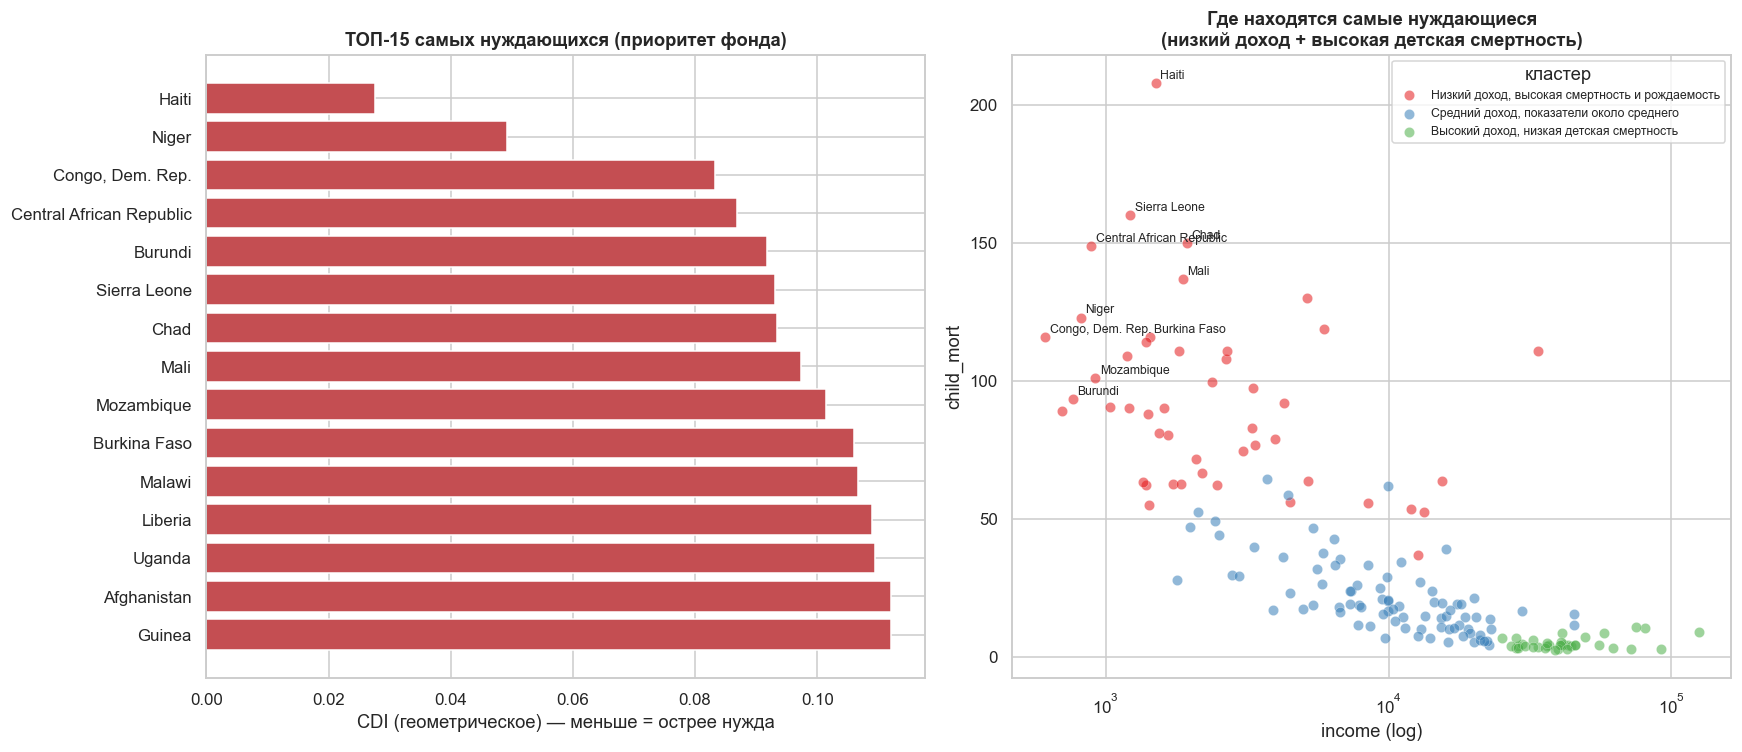

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- топ-15 по приоритету (меньше CDI = острее нужда) ---
top15 = needy.head(15).iloc[::-1]
ax[0].barh(top15["country"], top15["CDI_geom"], color="#C44E52")
ax[0].set_xlabel("CDI (геометрическое) — меньше = острее нужда")
ax[0].set_title("ТОП-15 самых нуждающихся (приоритет фонда)", fontweight="bold")

# --- все страны: income vs child_mort, нуждающиеся подписаны ---
for name in order_names:
    sub = df[df["target_name"] == name]
    ax[1].scatter(sub["income"], sub["child_mort"], s=45, alpha=.55, label=name,
                  color=palette[name], edgecolor="white", linewidth=.3)
ax[1].set_xscale("log")
for _, r in needy.head(10).iterrows():
    ax[1].annotate(r["country"], (r["income"], r["child_mort"]),
                   fontsize=8, xytext=(3, 3), textcoords="offset points")
ax[1].set_xlabel("income (log)"); ax[1].set_ylabel("child_mort")
ax[1].set_title("Где находятся самые нуждающиеся\n(низкий доход + высокая детская смертность)",
                fontweight="bold")
ax[1].legend(fontsize=8, title="кластер")

plt.tight_layout()
plt.show()

### Итоги Шага 6 — что в итоге работает лучше всего

- **KMeans (Шаг 2–3)** хорош, чтобы **определить группу** нуждающихся многомерно
  (по всем 9 признакам сразу), без ручных порогов.
- **Композитный индекс (геометрический)** хорош, чтобы **приоритизировать внутри
  группы** — даёт непрерывный рейтинг, по которому фонд выбирает top-N под бюджет.
- **Геометрическое среднее лучше арифметического** для этой цели: оно строже к
  дисбалансу и не даёт одной сильной стороне маскировать провал. Но на «дне» рейтинга
  оба индекса и KMeans **согласованы** — список беднейших устойчив (это и есть главный
  результат).
- **Логрег (объяснимость)** показал: нужду определяют прежде всего **демографические
  исходы** (детская смертность, рождаемость, продолжительность жизни), а не сам по себе
  доход — что согласуется с мультиколлинеарностью и с находкой Шага 1.

**Рекомендуемый рабочий рецепт:** *KMeans → определить кластер нуждающихся →
ранжировать его геометрическим CDI → объяснить драйверы логрегом.* Три независимых
метода (профиль признаков, PCA, классификатор) и независимый индекс указывают на одни
и те же страны — вывод устойчив; размытой остаётся лишь граница «средние ↔ богатые».